<b><h2><center>Easy Visa Prediction</center></h2></b>

## Problem Statement

### Context

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.


### Objective

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

1.  Facilitate the process of visa approvals.
2.  Recommend a suitable profile for the applicants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.




### Data Description:

The data contains the different attributes of the employee and the employer. The detailed data dictionary is given below.

* case_id: ID of each visa application
* continent: Information of continent the employee
* education_of_employee: Information of education of the employee
* has_job_experience: Does the employee has any job experience? Y= Yes; N = No
* requires_job_training: Does the employee require any job training? Y = Yes; N = No
* no_of_employees: Number of employees in the employer's company
* yr_of_estab: Year in which the employer's company was established
* region_of_employment: Information of foreign worker's intended region of employment in the US.
* prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.
* unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.
* full_time_position: Is the position of work full-time? Y = Full-Time Position; N = Part-Time Position
* case_status: Flag indicating if the Visa was certified or denied

## Import necessary libraries

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# To tune model, get different metric scores, and split data
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder

# To impute missing values
from sklearn.impute import SimpleImputer
from sklearn import metrics

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To do hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To help with model building
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

# To suppress scientific notations
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

## Reading the dataset

In [ ]:
# uncomment and run the below code snippets if the dataset is present in the Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
visa_data = pd.read_csv('EasyVisa.csv')

In [ ]:
# copying data to another varaible to avoid any changes to original data
data = visa_data.copy()

## Overview of the dataset

### Displaying the first and last 5 rows of the dataset

In [ ]:
data.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
data.tail()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.570,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.790,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.850,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.770,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.910,Year,Y,Certified


In [ ]:
data.sample(10)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
4792,EZYV4793,Asia,Bachelor's,Y,N,4329,2002,South,106686.740,Year,Y,Certified
1439,EZYV1440,Asia,High School,Y,N,4952,1997,Northeast,115350.150,Year,Y,Denied
18991,EZYV18992,Asia,Master's,Y,N,795,1977,South,447.370,Hour,Y,Certified
21060,EZYV21061,Asia,Master's,Y,Y,2493,2006,South,93522.280,Year,Y,Certified
6391,EZYV6392,North America,Master's,Y,N,1999,2009,South,136.770,Hour,Y,Denied
426,EZYV427,Asia,Master's,N,N,2675,1997,Midwest,102915.070,Year,Y,Certified
3089,EZYV3090,Asia,Bachelor's,Y,N,1057,2003,South,61332.580,Year,Y,Certified
2572,EZYV2573,Asia,Master's,N,N,2674,1886,Midwest,17228.340,Year,Y,Certified
15713,EZYV15714,North America,Bachelor's,Y,N,423,1995,Midwest,68153.440,Year,N,Certified
19258,EZYV19259,Asia,Bachelor's,Y,Y,2135,1966,South,88336.610,Year,Y,Denied


### Understand the shape of the dataset.

In [ ]:
data.shape

(25480, 12)

* There are 25480 observations and 12 columns in the dataset

In [ ]:
# fixing column names
data.columns = [c.replace(" ", "_") for c in data.columns]

### Check the data types of the columns for the dataset.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


**Data Overview:**
* The dataset contains 25,480 entries and 12 columns. All columns have no missing values.

* **case_id** is a unique identifier and is not used for analysis. we can drop it.



In [ ]:
# When we check the data and see that there is no pattern in the id column. so we can drop it.
data.drop("case_id", axis=1, inplace=True)

In [ ]:
# Check the info of data set after dropping the columns
# We see the column is now dropped from data set.
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   continent              25480 non-null  object 
 1   education_of_employee  25480 non-null  object 
 2   has_job_experience     25480 non-null  object 
 3   requires_job_training  25480 non-null  object 
 4   no_of_employees        25480 non-null  int64  
 5   yr_of_estab            25480 non-null  int64  
 6   region_of_employment   25480 non-null  object 
 7   prevailing_wage        25480 non-null  float64
 8   unit_of_wage           25480 non-null  object 
 9   full_time_position     25480 non-null  object 
 10  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 2.1+ MB


### Checking for duplicate values

In [ ]:
# let's check for duplicate observations
data.duplicated().sum()

np.int64(0)

* There are no duplicates in the data set.

### Checking Statistical Summary of the dataset

In [ ]:
#Descriptive Statistics for Numerical Columns
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_employees,25480.000,5667.043,22877.929,-26.000,1022.000,2109.000,3504.000,602069.000
yr_of_estab,25480.000,1979.410,42.367,1800.000,1976.000,1997.000,2005.000,2016.000
prevailing_wage,25480.000,74455.815,52815.942,2.137,34015.480,70308.210,107735.513,319210.270


**Observations on numeric statistical summary:**

**no_of_employees**: This column exhibits a wide range, with a concerning negative minimum value **(-26)**, which is an anomaly in the data and this requires cleaning. The maximum value 602069.00 is significantly higher than the 75th percentile, indicating a right-skewed distribution and the presence of potential outliers. This suggests many companies have few employees, while a few have a very large number.

**yr_of_estab**: The year of establishment spans a broad period (1800-2016), with a mean around 1979. The distribution is spread out normally and this is a year value, and  this feature might not be a primary influencer for deriving the case_status .

**prevailing_wage**: This column is right-skewed and shows a wide range, from a very low minimum value **(2.1367)** to a high maximum. The low minimum wage suggests a need for further investigation or handling. Higher prevailing wages are associated with higher chances of visa certification.

Overall, the numerical columns show good variance  and  there are potential outliers, particularly no_of_employees and prevailing_wage, which requires further data cleaning and investigation.

In [ ]:
#Descriptive Statistics for Categorical Columns
data.describe(include='object').T

,count,unique,top,freq
continent,25480,6,Asia,16861
education_of_employee,25480,4,Bachelor's,10234
has_job_experience,25480,2,Y,14802
requires_job_training,25480,2,N,22525
region_of_employment,25480,5,Northeast,7195
unit_of_wage,25480,4,Year,22962
full_time_position,25480,2,Y,22773
case_status,25480,2,Certified,17018


**Observations:**

**continent**: There are 6 unique continents. Asia is the most frequent continent, appearing 16,861 times, indicating a significant portion of applicants are from Asia.

**education_of_employee**: There are 4 unique education levels categories. 'Bachelor's' is the most common, with 10,234 occurrences.

**has_job_experience**: This is a binary variable with two unique values ('Y' for Yes, 'N' for No). 'Y' is more frequent, with 14,802 employees having  job experience.

**requires_job_training**: Another binary variable. 'N' (No) is more frequent, with 22,525 times, suggesting that most employees do not require job training.

**region_of_employment**: There are 5 unique regions of employment. 'Northeast' is the most frequent, with 7,195 occurrences.

**unit_of_wage**: There are 4 unique units of wage. 'Year' is the most common unit, used in 22,962 applications, indicating that most prevailing wages are reported annually.

**full_time_position**: A binary variable where 'Y' (Yes) is the most frequent, occurring 22,773 times, indicating that most visa applications
are full-time positions.

**case_status**: This is the target variable with two unique values: 'Certified' and 'Denied'.
'Certified' is the most frequent status, with 17,018 applications being certified. This indicates an imbalanced dataset, from 25480 applications only 17018 are certified, which might need to be addressed during model training.


In [ ]:
# list of all categorical variables
cat_col = data.select_dtypes(include='object').columns.tolist()

# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(data[column].value_counts(normalize=True))
    print("-" * 50)

continent
Asia            0.662
Europe          0.146
North America   0.129
South America   0.033
Africa          0.022
Oceania         0.008
Name: proportion, dtype: float64
--------------------------------------------------
education_of_employee
Bachelor's    0.402
Master's      0.378
High School   0.134
Doctorate     0.086
Name: proportion, dtype: float64
--------------------------------------------------
has_job_experience
Y   0.581
N   0.419
Name: proportion, dtype: float64
--------------------------------------------------
requires_job_training
N   0.884
Y   0.116
Name: proportion, dtype: float64
--------------------------------------------------
region_of_employment
Northeast   0.282
South       0.275
West        0.258
Midwest     0.169
Island      0.015
Name: proportion, dtype: float64
--------------------------------------------------
unit_of_wage
Year    0.901
Hour    0.085
Week    0.011
Month   0.003
Name: proportion, dtype: float64
------------------------------------------

## Summary of Categorical Variable Observations

**continent**: Asia is the dominant continent for visa applicants, accounting for a significantly higher proportion than all other continents (66.2%). This strong imbalance suggests that applicants from Asia might have unique characteristics or face specific processing patterns.

**education_of_employee**: 'Bachelor's' is the most common education level (40.2%), followed by 'Master's' (37.8%), 'High School' (13.4%), and 'Doctorate' (8.6%). This distribution indicates the typical educational background of visa applicants.

**has_job_experience**: A majority of applicants (58.1%) possess job experience ('Y'), while a substantial portion (41.9%) do not ('N'). This feature could be a significant determinant in visa approval.

**requires_job_training**: Most employees (88.4%) do not require job training ('N'), implying that most applicants are expected to be job-ready upon arrival, or that the positions they seek do not typically involve training.

**region_of_employment**: The 'Northeast' region appears to be the most popular intended employment location (28.2%), followed by 'South' (27.5%) and 'West' (25.8%). The other regions have fewer applicants. This geographical preference could be influenced by economic opportunities or established communities.

**unit_of_wage**: 'Year' is the most frequent unit of wage (90.1%), indicating that most prevailing wages are reported annually. 'Hour' (8.5%), 'Week' (1.1%), and 'Month' (0.3%) are much less common.

**full_time_position**: The vast majority of visa applications are for full-time positions ('Y') at 89.4%. This suggests that the visa program primarily caters to full-time employment opportunities.

**case_status**: The target variable shows an imbalance, with 'Certified' cases (66.8%) significantly outnumbering 'Denied' cases (33.2%). This imbalance needs to be considered during model training to prevent bias towards the majority class.

In [ ]:
data.isna().sum()

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


*  There are no missing values in the data.




In [ ]:
# In the data set, we see majority of columns are categorical and only few are numreric. Lets segregate the list of features based on type of column for making more impactful visualizations.

# Selecting numerical columns and categorical columns dynamically
all_features = data.columns.tolist()

# Identify categorical columns (object dtype) excluding 'case_id'
Cat_features = data.select_dtypes(include='object').columns.tolist()

# Identify numerical columns (int64 or float64 dtypes)
num_features = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('All Features: ' + str(all_features))
print('Numerical Features: ' + str(num_features))
print('Categorical Features: ' + str(Cat_features))

All Features: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'no_of_employees', 'yr_of_estab', 'region_of_employment', 'prevailing_wage', 'unit_of_wage', 'full_time_position', 'case_status']
Numerical Features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
Categorical Features: ['continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


## Exploratory Data Analysis

# Univariate analysis

We will plot Histograms, boxplots for Numeric Variabels to understand the data better.

Bar plots for visualising the categorical variables.

## Numeric variables Analysis

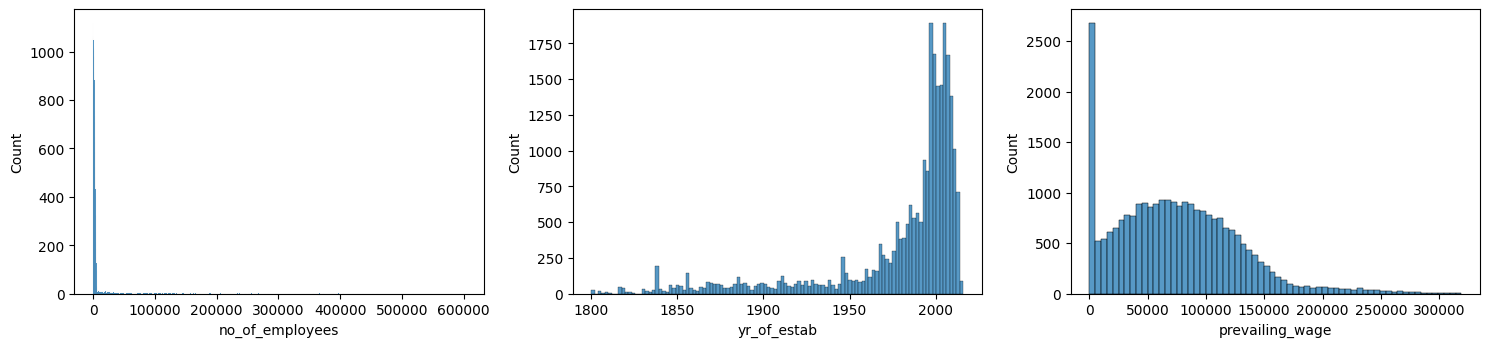

In [ ]:
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the histogram for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.histplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();   # to add spacing between plots

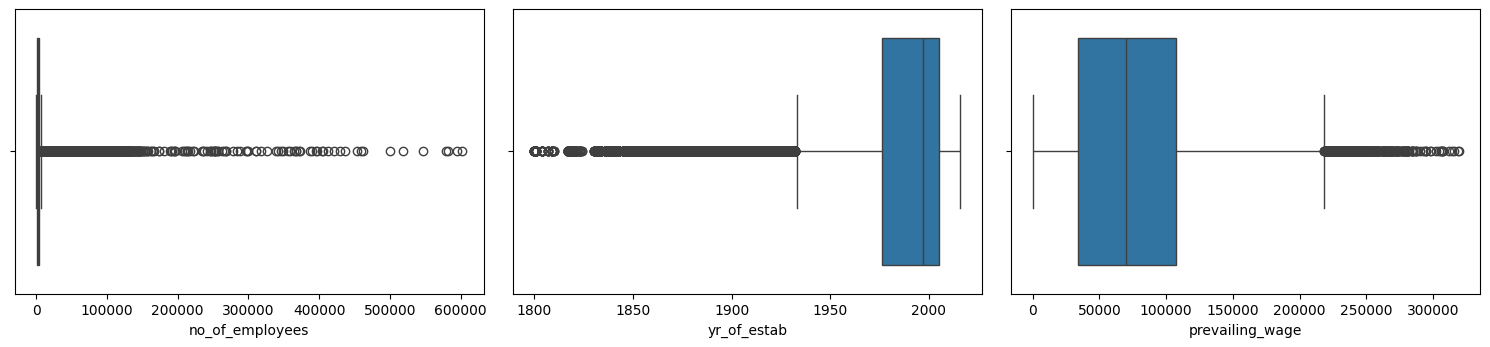

In [ ]:
#We will plot Box plots for the numeric features
# defining the figure size
plt.figure(figsize=(15, 10))

# plotting the boxplot for each numerical feature
for i, feature in enumerate(num_features):
    plt.subplot(3, 3, i+1)    # assign a subplot in the main plot
    sns.boxplot(data=data, x=feature)    # plot the histogram

plt.tight_layout();    # to add spacing between plots

**Observations from Numeric variables Analysis:**

**no_of_employees**:

- From the Histogram plot, the distribution is highly right-skewed, indicating that a large majority of employers have a relatively small number of employees, while a few employers have a very high number of employees.

- From Boxplot, it clearly shows very large number of  outliers on the upper end, showing the right-skewness.  The presence of negative minimum value (-26) observed in statistical summary is an anomaly that should be addressed in data cleaning.

**yr_of_estab:**

- From the Histogram plot,  The distribution appears to be somewhat spread out, with a noticeable peak around the late 1900s to early 2000s, suggesting more companies were established during these periods.

- From Boxplot, This plot shows  some outliers on the lower end (very old companies).

**prevailing_wage:**

- From the Histogram plot,  This feature also exhibits a strong right-skewed distribution. Most prevailing wages are concentrated at the lower end of the histogram, with a long tail having much higher wages.

- From Boxplot, prevailing_wage shows a significant number of outliers on the higher side. The very low minimum value (around 2.13) noted in the descriptive statistics is also visible, appearing as an extreme low outlier, which might indicate data entry errors or specific low-wage categories that need investigation.

In [ ]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top, sorted from higher to lower

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n], # Sort by frequency (descending) by default
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

##Observations on continent

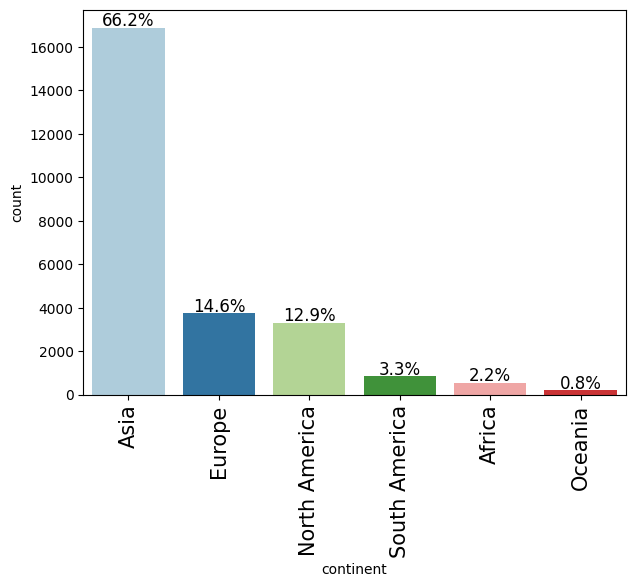

In [ ]:
labeled_barplot(data, 'continent', perc=True)

- **continent**: The bar plot clearly shows that **Asia** is the dominant continent for visa applicants, accounting for a significantly higher proportion than all other continents. This strong imbalance suggests that applicants from Asia might have unique characteristics or face specific processing patterns.

##Observations on education_of_employee

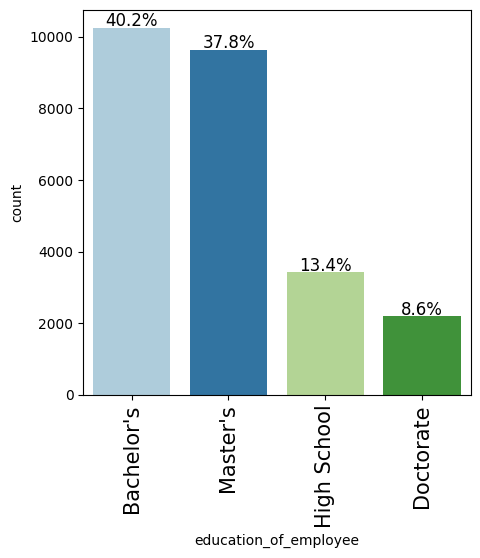

In [ ]:
labeled_barplot(data, 'education_of_employee', perc=True)


- **education_of_employee**: The bar plot confirms 'Bachelor's' as the most common education level, followed by 'Master's', 'High School', and 'Doctorate'. This distribution indicates the typical educational background of visa applicants.

##Observations on has_job_experience

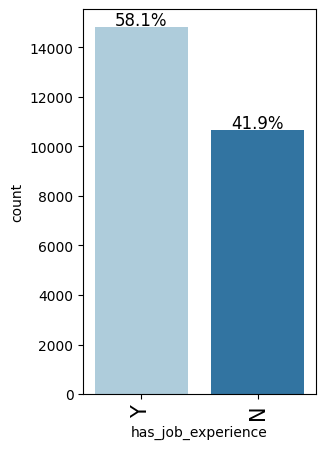

In [ ]:
labeled_barplot(data, 'has_job_experience', perc=True)


- **has_job_experience**: The bar plot visualizes that a majority of applicants (around 60%) possess job experience ('Y'), while a substantial portion (around 40%) do not ('N'). This feature could be a significant determinant in visa approval.

##Observations on requires_job_training

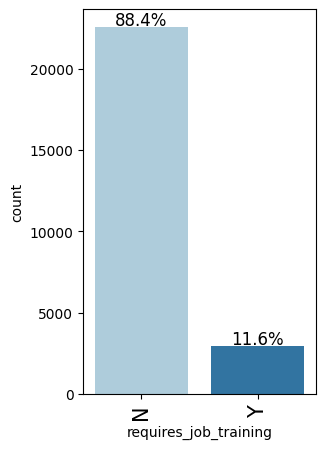

In [ ]:
labeled_barplot(data, 'requires_job_training', perc=True)


- **requires_job_training**: The bar plot overwhelmingly shows that most employees ('N' for No) do not require job training. This implies that most applicants are expected to be job-ready upon arrival, or that the positions they seek do not typically involve training.


##Observations on region_of_employment

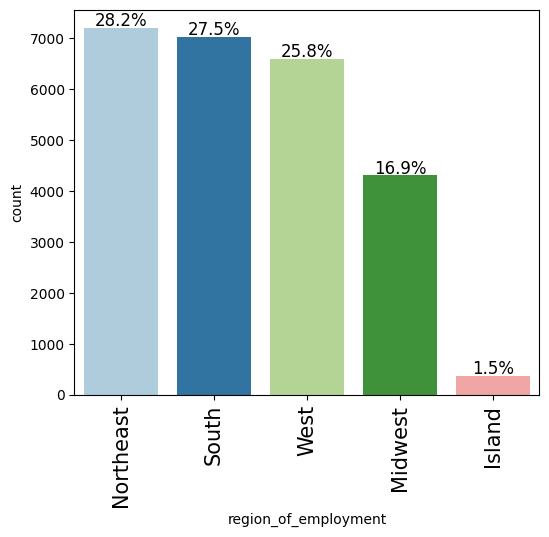

In [ ]:
labeled_barplot(data, 'region_of_employment', perc=True)

- **region_of_employment**: The 'Northeast' region appears to be the most popular intended employment location, followed by 'South' and 'West'. The other regions have fewer applicants. This geographical preference could be influenced by economic opportunities or established communities.

##Observations on unit_of_wage





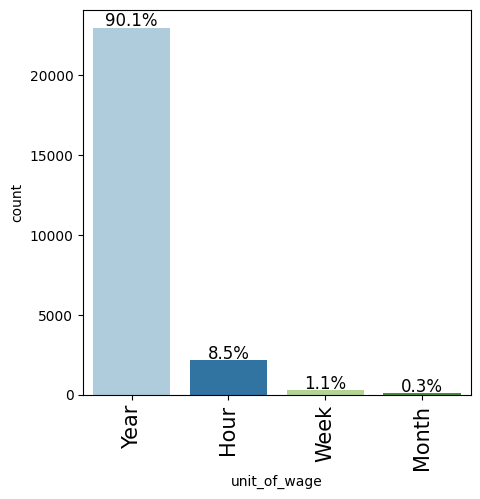

In [ ]:
labeled_barplot(data, 'unit_of_wage', perc=True)

- **unit_of_wage**: The bar plot prominently displays 'Year' as the most frequent unit of wage, indicating that most prevailing wages are reported annually. 'Hour', 'Week', and 'Month' are much less common.

##Observations on full_time_position





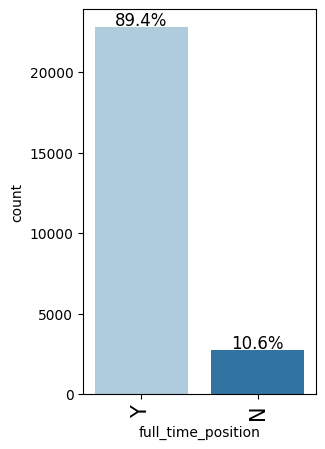

In [ ]:
labeled_barplot(data, 'full_time_position', perc=True)

- **full_time_position**: The vast majority of visa applications are for full-time positions ('Y'), as shown by the high bar for 'Y'. This suggests that the visa program primarily caters to full-time employment opportunities.

##Observations on case_status





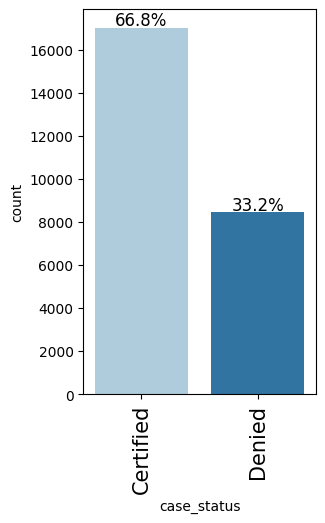

In [ ]:
labeled_barplot(data, 'case_status', perc=True)

- **case_status**: The bar plot for case_status visually confirms the imbalance, with 'Certified' cases significantly outnumbering 'Denied' cases. This imbalance needs to be considered during model training to prevent bias towards the majority class.


# Bivariate Analysis

Let's check for correlations.

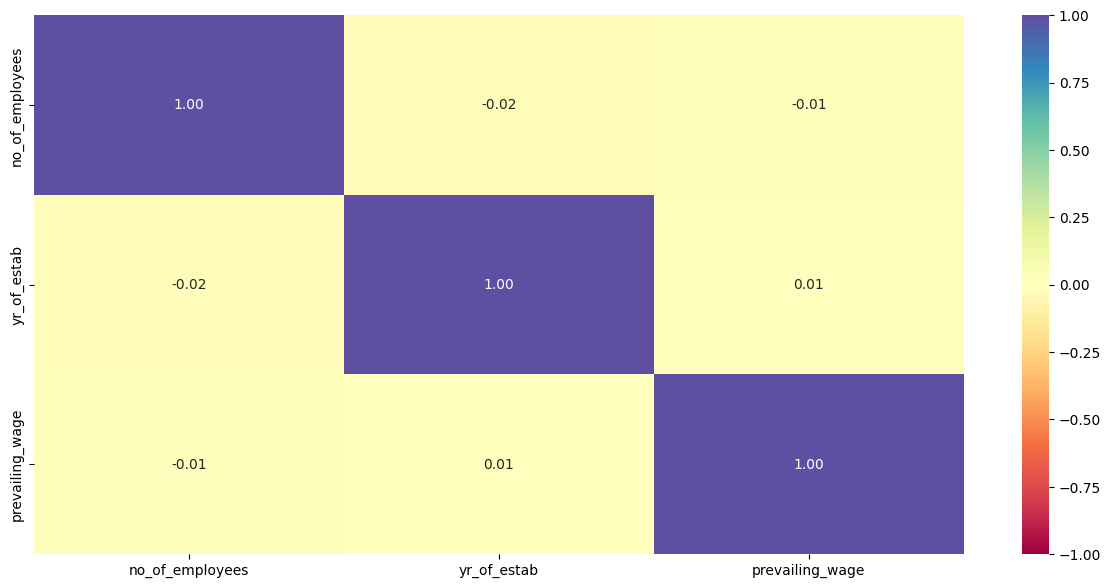

In [ ]:
plt.figure(figsize=(15, 7))
sns.heatmap(data[num_features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

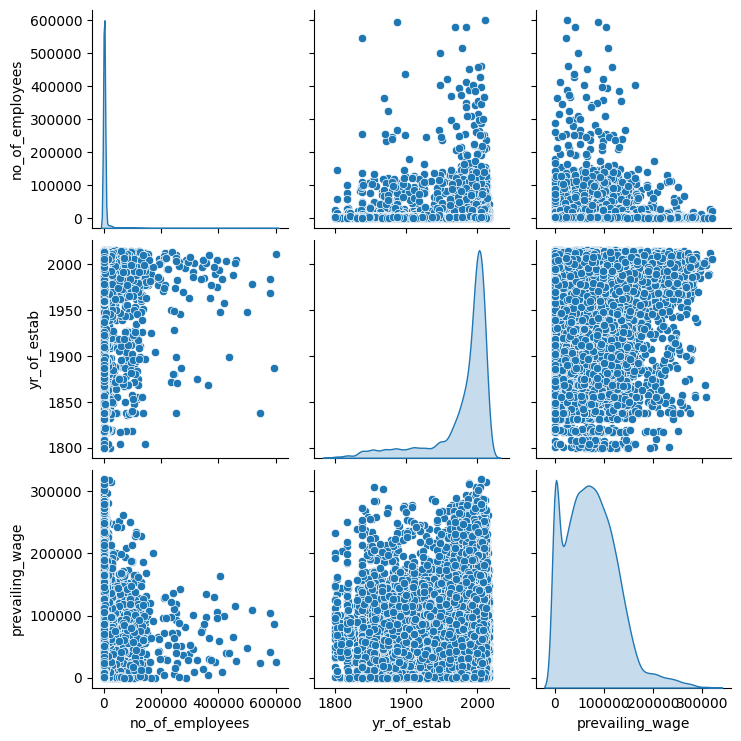

In [ ]:
sns.pairplot(data=data[num_features], diag_kind="kde")
plt.show()

##**Observations on numeric columns based on heatmap and Pairplot**



*   **No significant correlations**: The heatmap shows very low correlation coefficients (close to 0) between **`no_of_employees`**, **`yr_of_estab`**, and **`prevailing_wage`**. This indicates that there isn't a strong linear relationship between these numerical variables.
*   **Independent features**: The lack of strong correlation suggests that these numerical features are largely independent of each other within the dataset. For instance, the number of employees in a company does not linearly dictate its year of establishment or the prevailing wage offered.
*   **Implications that we have on Model Building**: This low correlation is generally a good sign for modeling, as it means multicollinearity is not a significant concern among these specific numerical features. Each feature might contribute unique information to the model.

* Even the pairplot shows us that  there is no proper corelation between the numercic attributes. there is no particular pattern can be observed among these three variables.

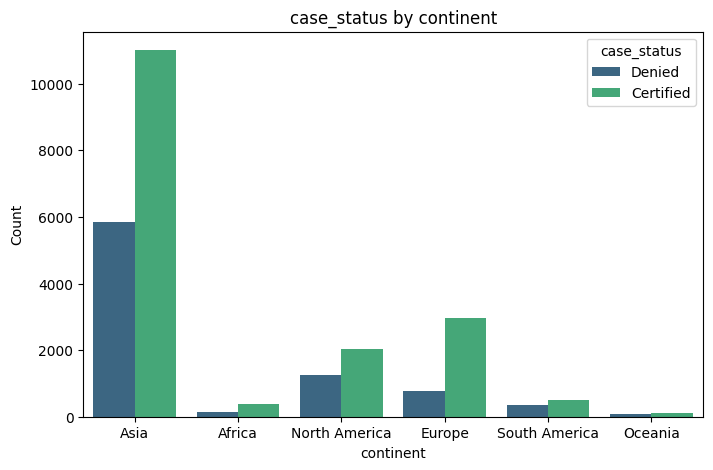

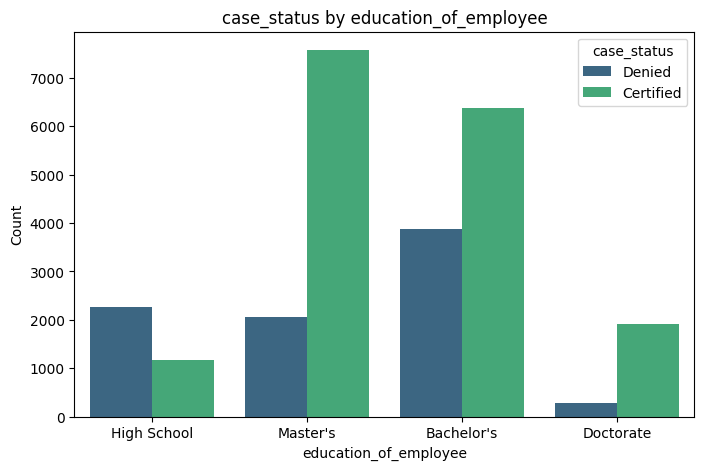

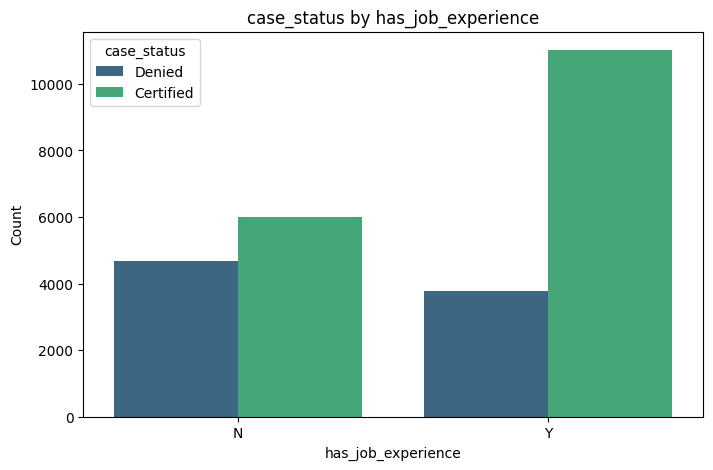

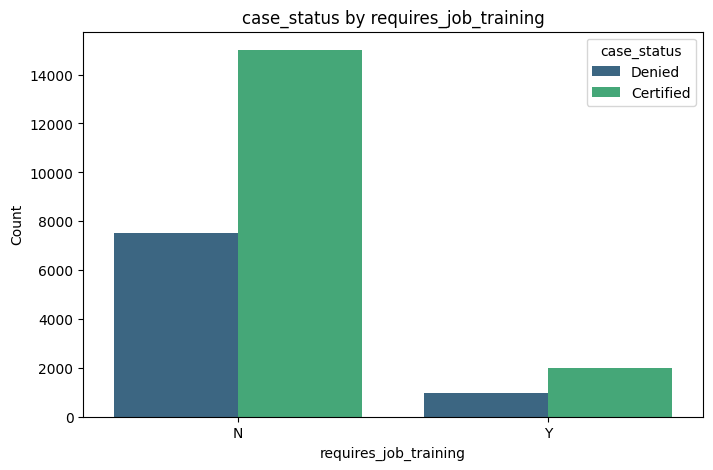

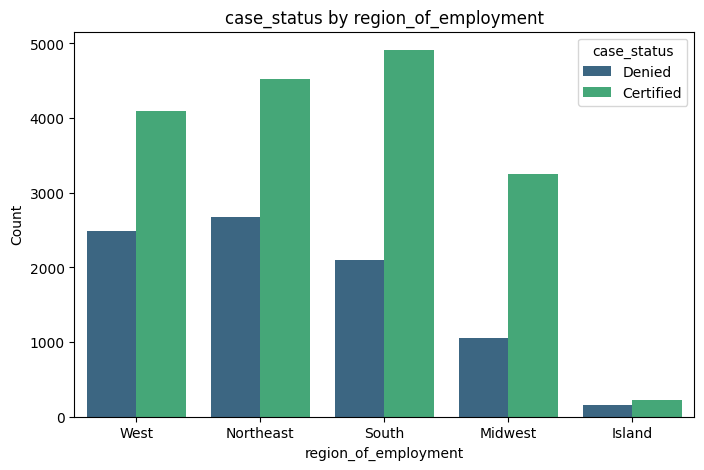

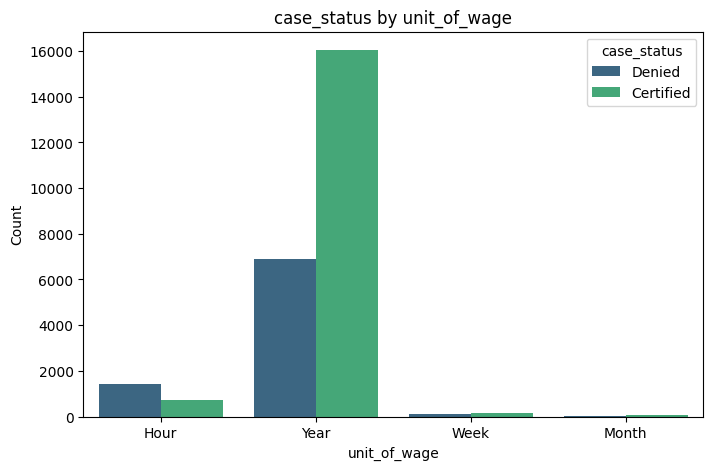

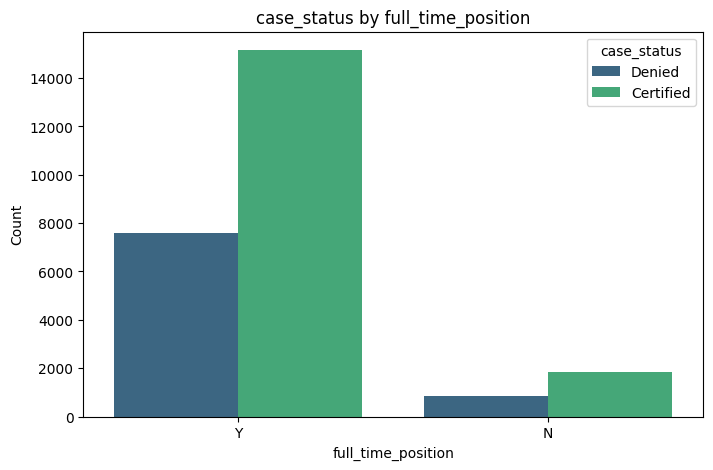

In [ ]:
#Lets explore the bivariate analysis of all categorical varibles with hue as our target varable (case_status)
categorical_features_for_analysis = [
    'continent',
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'region_of_employment',
    'unit_of_wage',
    'full_time_position'
]
for col in categorical_features_for_analysis:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=data, x=col, hue="case_status", palette="viridis")
    plt.title(f"case_status by {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [ ]:
#Create crosstabs for each variable in categorical_features_for_analysis
for feature in categorical_features_for_analysis:
    print(f"\n--- Analysis for: {feature} vs. case_status ---")
    crosstab_df = pd.crosstab(data[feature], data['case_status'], normalize='index') * 100
    display(crosstab_df.round(2))



--- Analysis for: continent vs. case_status ---


case_status,Certified,Denied
continent,,
Africa,72.050,27.950
Asia,65.310,34.690
Europe,79.230,20.770
North America,61.880,38.120
Oceania,63.540,36.460
South America,57.860,42.140



--- Analysis for: education_of_employee vs. case_status ---


case_status,Certified,Denied
education_of_employee,,
Bachelor's,62.210,37.790
Doctorate,87.230,12.770
High School,34.040,65.960
Master's,78.630,21.370



--- Analysis for: has_job_experience vs. case_status ---


...

case_status,Certified,Denied
region_of_employment,,
Island,60.270,39.730
Midwest,75.530,24.470
Northeast,62.900,37.100
South,70.020,29.980
West,62.250,37.750



--- Analysis for: unit_of_wage vs. case_status ---


case_status,Certified,Denied
unit_of_wage,,
Hour,34.630,65.370
Month,61.800,38.200
Week,62.130,37.870
Year,69.890,30.110



--- Analysis for: full_time_position vs. case_status ---


case_status,Certified,Denied
full_time_position,,
N,68.530,31.470
Y,66.580,33.420


##Observations from Bivariate Analysis (Categorical Features vs. case_status)

*   **Continent vs. Case Status**:
    *   Asia, despite having the highest number of applicants, had a certification rate of 65.31%, which was lower than Europe (79.23%) and Africa (72.05%).
    *   South America (57.86%) and Oceania (63.54%) also showed lower certification rates compared to Europe and Africa.
    *   North America had a certification rate of 61.88%.
*   **Education Level vs. Case Status**:
    *   Higher education levels strongly correlate with higher certification rates: Doctorate (87.23%), Master's (78.63%), Bachelor's (62.21%), and High School (34.04%).
*   **Job Experience vs. Case Status**:
    *   Applicants with job experience ('Y') had a significantly higher certification rate of 74.48% compared to those without job experience ('N') at 56.13%.
*   **Job Training Requirement vs. Case Status**:
    *   Surprisingly, applications requiring job training ('Y') had a slightly higher certification rate of 67.88% compared to those not requiring training ('N') at 66.65%. This contradicted the initial hypothesis that "job-ready" applicants would be preferred.
*   **Region of Employment vs. Case Status**:
    *   The Midwest region had the highest certification rate at 75.53%, followed by the South (70.02%).
    *   The Island region showed the lowest certification rate among all regions at 60.27%.
*   **Unit of Wage vs. Case Status**:
    *   "Yearly" wages were associated with the highest certification rate (69.89%).
    *   "Hourly" wages had a significantly lower certification rate at 34.63%, suggesting that annually salaried positions might be perceived as more stable or higher-skilled.
*   **Full-Time Position vs. Case Status**:
    *   Contrary to the initial expectation, part-time positions ('N') showed a slightly higher certification rate of 68.53% compared to full-time positions ('Y') at 66.58%.

### Insights or Next Steps

*   The findings suggest that factors such as higher education, job experience, and yearly wages are generally associated with a higher likelihood of visa certification. This could guide applicants in highlighting relevant qualifications or employers in structuring visa applications.

*   Further investigation is needed to understand the surprising certification rates for `requires_job_training` and `full_time_position`. It would be beneficial to explore confounding factors or specific nuances within these categories (e.g., specific types of job training, industry for part-time roles) that might explain the observed trends.


To analyze the relationship between numerical features and the 'case_status' target variable, Let's create box plots for each numerical feature, comparing their distributions for applicants whose case is certified and whose case is denied.

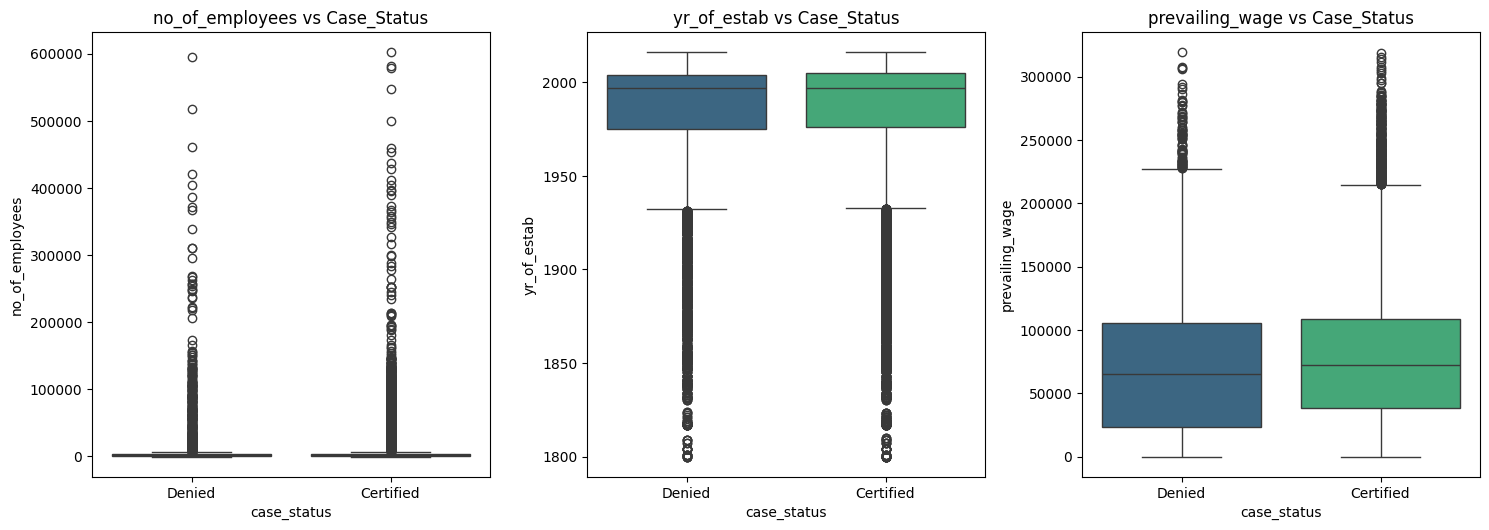

In [ ]:
plt.figure(figsize=(15, 10))

for i, feature in enumerate(num_features):
    plt.subplot(2, 3, i + 1)  # Arrange plots in a 2x3 grid
    sns.boxplot(data=data, y=feature, x='case_status', palette='viridis')
    plt.title(f'{feature} vs Case_Status')

plt.tight_layout()
plt.show()

##Observations from Bivariate Analysis (Numerical Features vs. Case_Status)

*   **no_of_employees vs. case_status**:
    *   Both 'Certified' and 'Denied' cases show a similar right-skewed distribution for `no_of_employees`. This means that most applications come from companies with fewer employees, with a long tail representing very large companies.

    *   There isn't a clear distinction in the median or interquartile range (IQR) of `no_of_employees` between certified and denied cases, suggesting that the number of employees alone might not be a primary factor in visa status.

*   **yr_of_estab vs. case_status**:
    *   The distributions of `yr_of_estab` are similar for both 'Certified' and 'Denied' cases. The median year of establishment and the overall spread are consistent across both visa statuses.

    *   This indicates that the age of the employer's company does not strongly correlate with the likelihood of visa certification or denial.

*   **prevailing_wage vs. case_status**:
    *   A noticeable difference exists for `prevailing_wage` between 'Certified' and 'Denied' cases.

    *   'Certified' cases generally have a slightly higher median `prevailing_wage` compared to 'Denied' cases.

    *   The wage distribution for 'Certified' cases tends to be wider towards higher values, with more high-wage outliers being certified. Conversely, 'Denied' cases are more concentrated at the lower end of the wage spectrum.

    *   This suggests that a higher `prevailing_wage` might be a favorable factor for visa certification, potentially indicating higher-skilled positions or more competitive offers that align with labor market requirements.

### Overall Insights

*   Among the numerical features, `prevailing_wage` shows the most discernible relationship with `case_status`, with higher wages generally correlating with a higher likelihood of certification. This highlights the importance of fair compensation in visa approvals.

*   `no_of_employees` and `yr_of_estab` do not appear to be strong individual predictors of `case_status` based on these bivariate analyses, as their distributions are quite similar across both certified and denied categories.

# Data Preprocessing

## Handle Negative no_of_employees



- We will address the earlier identified anomaly where 'no_of_employees' has a negative minimum value (-26) observed in statistical summary.

- We can replace negative values with a suitable imputation strategy (e.g., median or 0, with rationale). But we need to confirm with business regarding the negative data values whether they have mis-typed the values with '-' or are they really negative during data collection.

- To address the anomaly of negative 'no_of_employees', here when we look at the data in csv, it gives us the sense that they have mis-typed the values with '-'.

- So here in this case, imputing the negative values with 0 or mean or median will introduce bias to the data. To avoid that we will take the absolute value by removing '-' befor the number.



In [ ]:
#lets check how many observations which have negative no_of_employees.
data[data['no_of_employees'] < 0].shape[0]

33

In [ ]:
negative_no_emp_data = data[data['no_of_employees'] < 0]
negative_no_emp_data

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
245,Europe,Master's,N,N,-25,1980,Northeast,39452.990,Year,Y,Certified
378,Asia,Bachelor's,N,Y,-11,2011,Northeast,32506.140,Year,Y,Denied
832,South America,Master's,Y,N,-17,2002,South,129701.940,Year,Y,Certified
2918,Asia,Master's,Y,N,-26,2005,Midwest,112799.460,Year,Y,Certified
6439,Asia,Bachelor's,N,N,-14,2013,South,103.970,Hour,Y,Denied
6634,Asia,Bachelor's,Y,N,-26,1923,West,5247.320,Year,Y,Denied
7224,Europe,Doctorate,N,N,-25,1998,Midwest,141435.950,Year,Y,Certified
7281,Asia,High School,N,N,-14,2000,Midwest,58488.500,Year,Y,Denied
7318,Asia,Bachelor's,Y,Y,-26,2006,South,115005.610,Year,Y,Certified
7761,Asia,Master's,N,N,-11,2009,Midwest,38457.510,Year,Y,Certified


In [ ]:
# There are 33 observations with negative values.
data['no_of_employees'] = np.abs(data['no_of_employees'])
print(f"Minimum value of no_of_employees after handling negative values: {data['no_of_employees'].min()}")

Minimum value of no_of_employees after handling negative values: 11


In [ ]:
# We see after the impute, there are no negative values in the column.
data[data['no_of_employees'] < 0].shape[0]

0

## Handle Missing Values

In [ ]:
# checking missing values
display(data.isnull().sum())

,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0
full_time_position,0


**Observations from Missing Value Treatment:**

The output above shows the count of missing values for each column. Based on this, we can conclude that there are no mising values to be treated by imputation with appropriate values.

## Feature Engineering

We can derive a new numerical feature 'company_age' from 'yr_of_estab' by calculating the age of the company (current year - 'yr_of_estab'). Drop the original 'yr_of_estab' column.

In [ ]:
#before the new column added to the dataset
data.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,Asia,High School,N,N,14513,2007,West,592.203,Hour,Y,Denied
1,Asia,Master's,Y,N,2412,2002,Northeast,83425.650,Year,Y,Certified
2,Asia,Bachelor's,N,Y,44444,2008,West,122996.860,Year,Y,Denied
3,Asia,Bachelor's,N,N,98,1897,West,83434.030,Year,Y,Denied
4,Africa,Master's,Y,N,1082,2005,South,149907.390,Year,Y,Certified


In [ ]:
#Derive company_age from yr_of_estab
current_year = 2025
data['company_age'] = current_year - data['yr_of_estab']
data.drop('yr_of_estab', axis=1, inplace=True)

display(data['company_age'].value_counts().sort_index())


,count
company_age,
9,23
10,64
11,175
12,533
13,492
...,...
216,9
218,6
221,18


In [ ]:
#We will create a new categorical variable called company_age_group by dividing the company_age into five distinct categories with descriptive labels:

# 'Very Young', 'Young', 'Established', 'Mature', and 'Veteran'.

# This will help us understanding the relationship between the company's age and other factors in a more interpretable way.

# Using np.inf for the upper bound of the last bin to ensure all values are covered
bins = [0, 10, 20, 50, 100, np.inf]
labels = ['Very Young', 'Young', 'Established', 'Mature', 'Veteran']
data['company_age_group'] = pd.cut(data['company_age'], bins=bins, labels=labels, right=False, include_lowest=True)

display(data['company_age_group'].value_counts().sort_index())

#We have derived the company_age_group from Company_age. so we dont need the company_age column. we can drop it.
data.drop('company_age', axis=1, inplace=True)

data.head()

,count
company_age_group,
Very Young,23
Young,5677
Established,13454
Mature,3304
Veteran,3022


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,company_age_group
0,Asia,High School,N,N,14513,West,592.203,Hour,Y,Denied,Young
1,Asia,Master's,Y,N,2412,Northeast,83425.650,Year,Y,Certified,Established
2,Asia,Bachelor's,N,Y,44444,West,122996.860,Year,Y,Denied,Young
3,Asia,Bachelor's,N,N,98,West,83434.030,Year,Y,Denied,Veteran
4,Africa,Master's,Y,N,1082,South,149907.390,Year,Y,Certified,Established


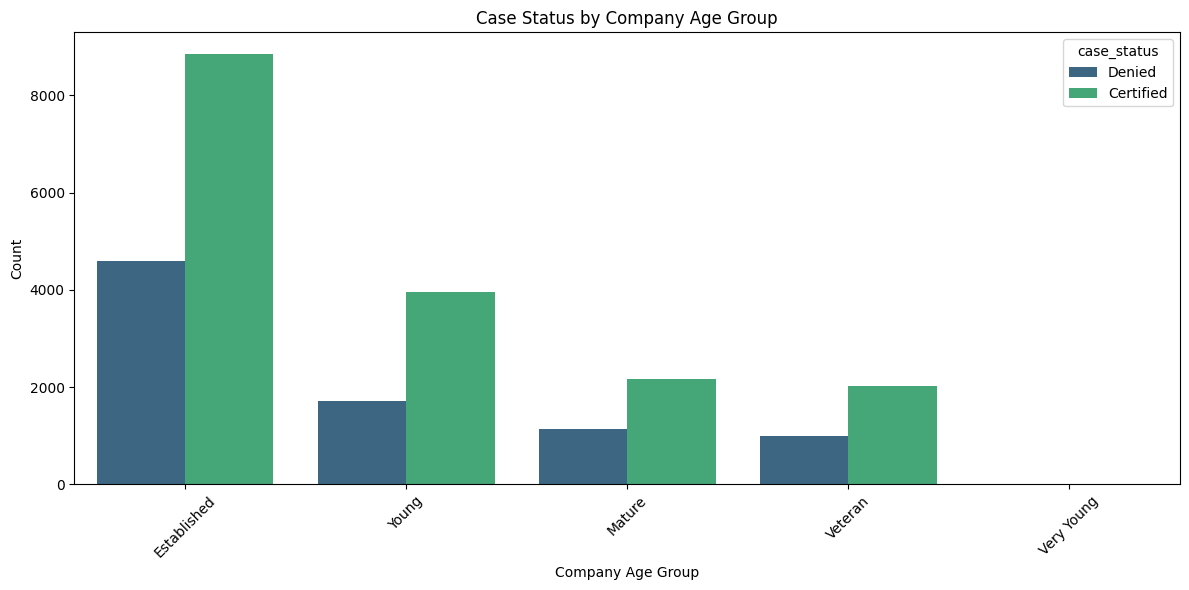

In [ ]:
#Lets analyze `company_age_group` vs. `case_status`
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='company_age_group', hue='case_status', palette='viridis', order=data['company_age_group'].value_counts().index)
plt.title('Case Status by Company Age Group')
plt.xlabel('Company Age Group')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
print('\n--- Analysis for: company_age_group vs. case_status ---')
crosstab_df_company_age_group = pd.crosstab(data['company_age_group'], data['case_status'], normalize='index') * 100
display(crosstab_df_company_age_group.round(2))


--- Analysis for: company_age_group vs. case_status ---


case_status,Certified,Denied
company_age_group,,
Very Young,56.520,43.480
Young,69.680,30.320
Established,65.790,34.210
Mature,65.680,34.320
Veteran,67.070,32.930


**Observations from `company_age_group` vs. `case_status`:**


- **Very Young companies (0-9 years old)** have the lowest visa certification rate at 56.52%. This suggests that newly established companies might face more challenges in getting visas certified.

- **Young companies (10-19 years old)** show the highest certification rate at 69.68%. This indicates that companies with a decade or two of experience tend to have the best success rates for visa applications.

- **For Established (20-49 years)**,** Mature (50-99 years), and Veteran (100+ years)** companies, the certification rates are relatively consistent, ranging from 65.68% to 67.07%. These rates are higher than 'Very Young' companies but slightly lower than 'Young' companies.

In summary, it appears that companies in the **'Young' category (10-19 years) **have the highest likelihood of visa certification, while 'Very Young' companies face the lowest. Companies older than 20 years show a stable, albeit slightly lower, certification rate compared to the 'Young' group.

## Standardize Prevailing Wage

- We see that in the data set, the prevailing wage column have values from different scales based on the unit of wage (Hourly, Monthly, Yearly). So for the model to better predict the target, we need to maintain data in the same scale. we need to convert the data to any one unit like Yearly.


- To standardize the 'prevailing_wage' to a 'Yearly' unit, we will define a function that takes the wage and its unit as input, then apply conversion factors (e.g., multiply hourly by 2080, weekly by 52, monthly by 12, and yearly by 1) to convert all wages to a yearly basis.


- We can standardize prevailing_wage, but we dont have enough information on how many hours worked for a week and for a month(we need to get this information from business) so here lets assume there that generally employees will work 40 hours/week * 52 weeks/year. Based on these will conver the prevailing_wage.



In [ ]:
#Before Standardizing the prevailing _wage to yearly,
data['prevailing_wage'].describe()

,prevailing_wage
count,25480.000
mean,74455.815
std,52815.942
min,2.137
25%,34015.480
50%,70308.210
75%,107735.513
max,319210.270


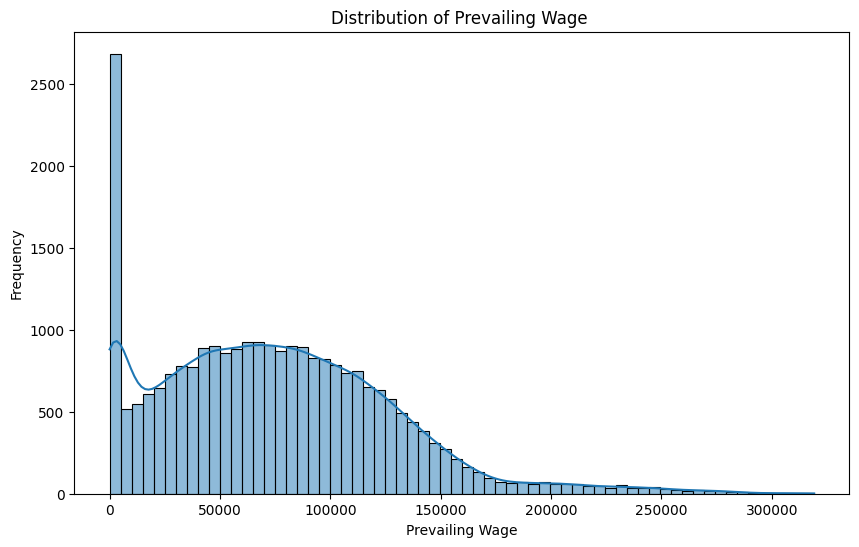

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='prevailing_wage', kde=True)
plt.title('Distribution of Prevailing Wage ')
plt.xlabel('Prevailing Wage')
plt.ylabel('Frequency')
plt.show()

In [ ]:
#Lets convert the wage to yearly using the below function
def convert_to_yearly_wage(row):
    wage = row['prevailing_wage']
    unit = row['unit_of_wage']

    if unit == 'Hour':
        return wage * 2080  # 40 hours/week * 52 weeks/year
    elif unit == 'Week':
        return wage * 52
    elif unit == 'Month':
        return wage * 12
    else:  # 'Year'
        return wage

data['prevailing_wage'] = data.apply(convert_to_yearly_wage, axis=1)

#we can drop the column unit_of_wage holding type of wage. this is  not needed now after the wage is converted to yearly.
data.drop('unit_of_wage', axis=1, inplace=True)
print("First 5 rows after standardizing prevailing_wage and dropping unit_of_wage:")
data.head()

First 5 rows after standardizing prevailing_wage and dropping unit_of_wage:


,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,full_time_position,case_status,company_age_group
0,Asia,High School,N,N,14513,West,1231782.032,Y,Denied,Young
1,Asia,Master's,Y,N,2412,Northeast,83425.650,Y,Certified,Established
2,Asia,Bachelor's,N,Y,44444,West,122996.860,Y,Denied,Young
3,Asia,Bachelor's,N,N,98,West,83434.030,Y,Denied,Veteran
4,Africa,Master's,Y,N,1082,South,149907.390,Y,Certified,Established


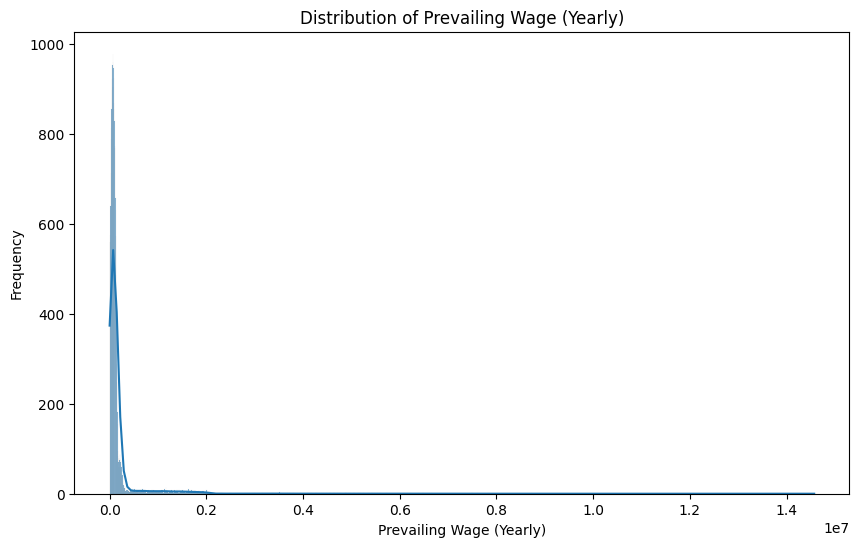

In [ ]:
#After standardization, all the data is on the same scale for this attribute

plt.figure(figsize=(10, 6))
sns.histplot(data=data, x='prevailing_wage', kde=True)
plt.title('Distribution of Prevailing Wage (Yearly)')
plt.xlabel('Prevailing Wage (Yearly)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
data1 = data.copy()
data1.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,region_of_employment,prevailing_wage,full_time_position,case_status,company_age_group
0,Asia,High School,N,N,14513,West,1231782.032,Y,Denied,Young
1,Asia,Master's,Y,N,2412,Northeast,83425.650,Y,Certified,Established
2,Asia,Bachelor's,N,Y,44444,West,122996.860,Y,Denied,Young
3,Asia,Bachelor's,N,N,98,West,83434.030,Y,Denied,Veteran
4,Africa,Master's,Y,N,1082,South,149907.390,Y,Certified,Established


## Encode Categorical Features


In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  object  
 1   education_of_employee  25480 non-null  object  
 2   has_job_experience     25480 non-null  object  
 3   requires_job_training  25480 non-null  object  
 4   no_of_employees        25480 non-null  int64   
 5   region_of_employment   25480 non-null  object  
 6   prevailing_wage        25480 non-null  float64 
 7   full_time_position     25480 non-null  object  
 8   case_status            25480 non-null  object  
 9   company_age_group      25480 non-null  category
dtypes: category(1), float64(1), int64(1), object(7)
memory usage: 1.8+ MB


In [ ]:
#lets convert all object type variables to categorical and then encode them.
for col in data1.select_dtypes(include='object').columns:
    data1[col] = data1[col].astype('category')
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   continent              25480 non-null  category
 1   education_of_employee  25480 non-null  category
 2   has_job_experience     25480 non-null  category
 3   requires_job_training  25480 non-null  category
 4   no_of_employees        25480 non-null  int64   
 5   region_of_employment   25480 non-null  category
 6   prevailing_wage        25480 non-null  float64 
 7   full_time_position     25480 non-null  category
 8   case_status            25480 non-null  category
 9   company_age_group      25480 non-null  category
dtypes: category(8), float64(1), int64(1)
memory usage: 598.6 KB


let's do label encoding for case_status, has_job_experience, requires_job_training , full_time_position , case_status with natural label encoding. And apply one-hot encoding for continent, region_of_employment



In [ ]:
#To convert the categorical 'case_status' column into a numerical format, I will use the map function to assign 0 to 'Denied' and 1 to 'Certified'.

data1['case_status'] = data1['case_status'].map({'Denied': 0, 'Certified': 1})
print(data1['case_status'].value_counts())
print(data1['case_status'].dtype)

# Natural label encoding for binary 'Y'/'N' columns
data1['has_job_experience'] = data1['has_job_experience'].map({'Y': 1, 'N': 0})
print(data1['has_job_experience'].value_counts())
print(data1['has_job_experience'].dtype)


data1['requires_job_training'] = data1['requires_job_training'].map({'Y': 1, 'N': 0})
print(data1['requires_job_training'].value_counts())
print(data1['requires_job_training'].dtype)

data1['full_time_position'] = data1['full_time_position'].map({'Y': 1, 'N': 0})
print(data1['full_time_position'].value_counts())
print(data1['full_time_position'].dtype)

#Education_level of employee
education_level = {
    "High School": 0,
    "Bachelor's": 1,
    "Master's": 2,
    "Doctorate": 3,
}
data1["education_of_employee"] = data1["education_of_employee"].map(education_level)
print(data1["education_of_employee"].value_counts())

#company_age_group encoding
company_age_group_mapping = {
    'Very Young': 0,
    'Young': 1,
    'Established': 2,
    'Mature': 3,
    'Veteran': 4
}
data1['company_age_group'] = data1['company_age_group'].map(company_age_group_mapping)
print(data1['company_age_group'].value_counts())
print(data1['company_age_group'].dtype)

# Apply one-hot encoding to 'continent', 'region_of_employment'
data1 = pd.get_dummies(data1, columns=['continent', 'region_of_employment'], drop_first=True)

# Convert boolean columns created by get_dummies to integer type (0 or 1)
for col in data1.select_dtypes(include='bool').columns:
    data1[col] = data1[col].astype(int)

# Display the first few rows to show the changes
data1.head()

case_status
1    17018
0     8462
Name: count, dtype: int64
category
has_job_experience
1    14802
0    10678
Name: count, dtype: int64
category
requires_job_training
0    22525
1     2955
Name: count, dtype: int64
category
full_time_position
1    22773
0     2707
Name: count, dtype: int64
category
education_of_employee
1    10234
2     9634
0     3420
3     2192
Name: count, dtype: int64
company_age_group
2    13454
1     5677
3     3304
4     3022
0       23
Name: count, dtype: int64
category


,education_of_employee,has_job_experience,requires_job_training,no_of_employees,prevailing_wage,full_time_position,case_status,company_age_group,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,0,14513,1231782.032,1,0,1,1,0,0,0,0,0,0,0,1
1,2,1,0,2412,83425.650,1,1,2,1,0,0,0,0,0,1,0,0
2,1,0,1,44444,122996.860,1,0,1,1,0,0,0,0,0,0,0,1
3,1,0,0,98,83434.030,1,0,4,1,0,0,0,0,0,0,0,1
4,2,1,0,1082,149907.390,1,1,2,0,0,0,0,0,0,0,1,0


In [ ]:
#lets check the data after encoding case_status, has_job_experience, requires_job_training , full_time_position , case_status
data1.head(10)

,education_of_employee,has_job_experience,requires_job_training,no_of_employees,prevailing_wage,full_time_position,case_status,company_age_group,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
0,0,0,0,14513,1231782.032,1,0,1,1,0,0,0,0,0,0,0,1
1,2,1,0,2412,83425.650,1,1,2,1,0,0,0,0,0,1,0,0
2,1,0,1,44444,122996.860,1,0,1,1,0,0,0,0,0,0,0,1
3,1,0,0,98,83434.030,1,0,4,1,0,0,0,0,0,0,0,1
4,2,1,0,1082,149907.390,1,1,2,0,0,0,0,0,0,0,1,0
5,2,1,0,2339,78252.140,1,1,1,1,0,0,0,0,0,0,1,0
6,1,0,0,4985,53635.390,1,1,2,1,0,0,0,0,0,0,1,0
7,1,1,0,3035,869917.984,1,0,4,0,0,1,0,0,0,0,0,1
8,1,0,0,4810,74362.190,1,1,1,1,0,0,0,0,1,0,0,0
9,3,1,0,2251,67514.760,1,1,2,0,1,0,0,0,0,0,1,0


In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   education_of_employee           25480 non-null  category
 1   has_job_experience              25480 non-null  category
 2   requires_job_training           25480 non-null  category
 3   no_of_employees                 25480 non-null  int64   
 4   prevailing_wage                 25480 non-null  float64 
 5   full_time_position              25480 non-null  category
 6   case_status                     25480 non-null  category
 7   company_age_group               25480 non-null  category
 8   continent_Asia                  25480 non-null  int64   
 9   continent_Europe                25480 non-null  int64   
 10  continent_North America         25480 non-null  int64   
 11  continent_Oceania               25480 non-null  int64   
 12  continent_South Am

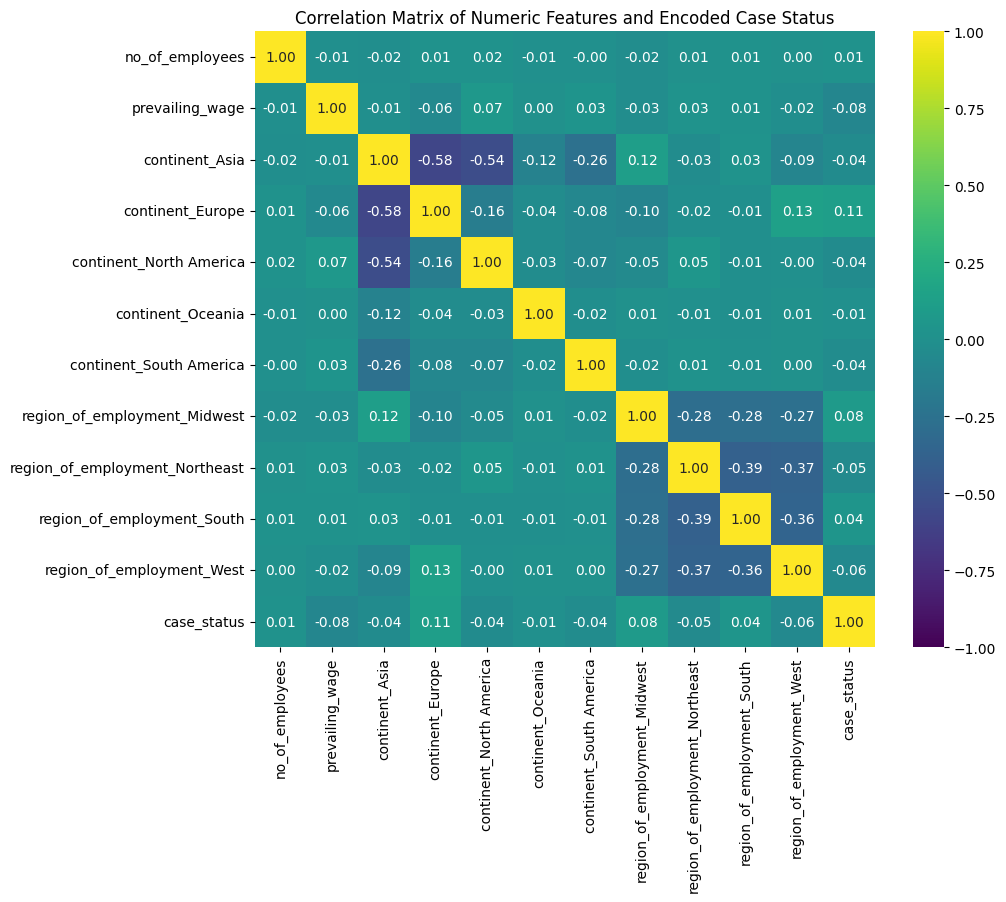

In [ ]:
# Identify numerical columns (int64 or float64 dtypes)
num_features = data1.select_dtypes(include=['int64', 'float64']).columns.tolist()

all_numeric_features = num_features + ['case_status']
plt.figure(figsize=(10, 8))
sns.heatmap(data1[all_numeric_features].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="viridis")
plt.title("Correlation Matrix of Numeric Features and Encoded Case Status")
plt.show()

**Correlations Among Numerical Features:**

- **Low Inter-feature Correlation:** The heatmap indicated very low correlation coefficients (close to 0) among **no_of_employees**, **yr_of_estab** (and subsequently **company_age**), and **prevailing_wage**.


- This suggests that these numerical features are largely independent of each other. This is generally a positive sign for modeling, as it implies that multicollinearity is not a significant issue among them, and each feature might contribute unique information.


**Observations and Good Predictors with case_status:**

- **prevailing_wage**: This feature shows the most relationship with case_status. Applications with a 'Certified' status generally exhibit a slightly higher median prevailing_wage compared to those with a 'Denied' status. Therefore, prevailing_wage is identified as a good predictor.


- **no_of_employees**: The distributions of no_of_employees are quite similar for both 'Certified' and 'Denied' cases. the number of employees, by itself, might not be a strong primary factor in determining visa status.


- **company_age** (derived from yr_of_estab): Similar to no_of_employees, the company_age distributions are largely consistent across both 'Certified' and 'Denied' cases. This indicates that the age of the employer's company does not appear to be a strong individual predictor of visa certification or denial.


In summary, among the numerical features analyzed, **prevailing_wage** stands out as the most promising predictor for case_status, primarily due to its noticeable correlation with visa certification outcomes.

In [ ]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   education_of_employee           25480 non-null  category
 1   has_job_experience              25480 non-null  category
 2   requires_job_training           25480 non-null  category
 3   no_of_employees                 25480 non-null  int64   
 4   prevailing_wage                 25480 non-null  float64 
 5   full_time_position              25480 non-null  category
 6   case_status                     25480 non-null  category
 7   company_age_group               25480 non-null  category
 8   continent_Asia                  25480 non-null  int64   
 9   continent_Europe                25480 non-null  int64   
 10  continent_North America         25480 non-null  int64   
 11  continent_Oceania               25480 non-null  int64   
 12  continent_South Am

In [ ]:
data1.isna().sum()

,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
prevailing_wage,0
full_time_position,0
case_status,0
company_age_group,0
continent_Asia,0
continent_Europe,0


##Outlier Detection and Treatment


- Among the above analysed numeric features **no_of_employees**, **yr_of_estab** **company_age** and **prevailing_wage**, we see that only **prevailing_wage** is a good predictor for Case_status. We can treat the outliers only in this column.


- And in this case we are building the models using many techniques like bagging and boosting and tuning the models so these models are not that sensitive to them. So We dont need to treat outliers in columns.


- I assume the outliers are genuine and im not going to treat them and introduce more bias to my models. we are working on DecisionTrees in this case , these tree based models are not effected or imapcted by outliers and there is no much need to treat them.

##Data Preparation for Modeling

In [ ]:
#set Random State
RS=1

X = data1.drop(["case_status"], axis=1)
y = data1["case_status"]

print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Shape of X: (25480, 16)
Shape of y: (25480,)


In [ ]:
# Splitting data into training, validation and test set:
# first we split data into 2 parts, say temporary and test

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RS, stratify=y
)

# then we split the temporary set into train and validation

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=RS, stratify=y_temp
)
print(X_train.shape, X_val.shape, X_test.shape)

(15288, 16) (5096, 16) (5096, 16)


In [ ]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in validation data =", X_val.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 15288
Number of rows in validation data = 5096
Number of rows in test data = 5096


# Model Building

## Model evaluation criterion

*   **Model Errors Defined:**
    *   A **False Positive** (Type I Error) occurs when the model predicts a visa will be **Certified**, but the visa is actually **Denied**.
    *   A **False Negative** (Type II Error) occurs when the model predicts a visa will be **Denied**, but the visa is actually **Certified**.
*   **Business Impact of Errors:**
    *   **False Positives** can lead to applicants and employers investing resources based on false expectations, potentially damaging EasyVisa's reputation and causing dissatisfaction.
    *   **False Negatives** can result in qualified applicants being overlooked, leading to missed opportunities for individuals, loss of talent for U.S. employers, and missed business for EasyVisa.
*   **Optimization Metric:**
    *   The **F1-score** is selected as the primary optimization metric. This is due to the significant negative consequences of both False Positives and False Negatives, as the F1-score provides a balanced measure by considering both precision and recall.

* **Summary**:  The balanced approach of the F1-score is crucial for this problem, as misclassifications in either direction carry substantial negative impacts for EasyVisa and its users.


**Let's define a function to output different metrics (including recall) on the train and test set and a function to show confusion matrix so that we do not have to use the same code repetitively while evaluating models.**

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Initial Model Building

### Model Building - Original Data

In [ ]:
base_models = []  # Empty list to store all the models
scores_original_validation = []
names = []  # Empty list to store name of the models

# Appending models into the list
base_models.append(("DecisionTreeClassifier", DecisionTreeClassifier(random_state=RS, class_weight='balanced')))
base_models.append(("BaggingClassifier", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RS, class_weight='balanced'), random_state=RS)))
base_models.append(("RandomForestClassifier", RandomForestClassifier(random_state=RS, class_weight='balanced')))
base_models.append(("GradientBoostingClassifier", GradientBoostingClassifier(random_state=RS)))
base_models.append(("AdaBoostClassifier", AdaBoostClassifier(random_state=RS)))
base_models.append(("XGBoostClassifier", XGBClassifier(random_state=RS, eval_metric='logloss', enable_categorical=True)))

print("\nTraining Performance:\n")
for name, model in base_models:
    model.fit(X_train, y_train)
    scores = f1_score(y_train, model.predict(X_train))
    print("{}: {}".format(name, scores))

print("\nValidation Performance:\n")
for name, model in base_models:
    model.fit(X_train, y_train)
    scores_val = f1_score(y_val, model.predict(X_val))
    names.append(name)
    scores_original_validation.append(scores_val)
    print("{}: {}".format(name, scores_val))


Training Performance:

DecisionTreeClassifier: 1.0
BaggingClassifier: 0.9880263028756502
RandomForestClassifier: 1.0
GradientBoostingClassifier: 0.8247670019378056
AdaBoostClassifier: 0.8183419923198554
XGBoostClassifier: 0.8937125748502994

Validation Performance:

DecisionTreeClassifier: 0.7489784004670169
BaggingClassifier: 0.7739194139194139
RandomForestClassifier: 0.7924635217452897
GradientBoostingClassifier: 0.824361820199778
AdaBoostClassifier: 0.8151671649904866
XGBoostClassifier: 0.8059618331243906


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in base_models:
    model.fit(X_train, y_train)
    scores_train = f1_score(y_train, model.predict(X_train))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference1 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference1))


Training and Validation Performance Difference:

DecisionTreeClassifier: Training Score: 1.0000, Validation Score: 0.7490, Difference: 0.2510
BaggingClassifier: Training Score: 0.9880, Validation Score: 0.7739, Difference: 0.2141
RandomForestClassifier: Training Score: 1.0000, Validation Score: 0.7925, Difference: 0.2075
GradientBoostingClassifier: Training Score: 0.8248, Validation Score: 0.8244, Difference: 0.0004
AdaBoostClassifier: Training Score: 0.8183, Validation Score: 0.8152, Difference: 0.0032
XGBoostClassifier: Training Score: 0.8937, Validation Score: 0.8060, Difference: 0.0878


- Let's compare the performance of the initial models to identify which ones are overfitting and which are generalizing well.

**Models trained on Original Data (F1-score):**

**Overfitting:**

- `DecisionTreeClassifier`: Training F1: 1.0000, Validation F1: 0.7490 (Difference: 0.2510)

- `BaggingClassifier`: Training F1: 0.9880, Validation F1: 0.7739 (Difference: 0.2141)

- `RandomForestClassifier`: Training F1: 1.0000, Validation F1: 0.7925 (Difference: 0.2075).

 These models show a significant drop in performance from the training set to the validation set, indicating they are overfitting to the training data.


**Generalizing Well:**

- `GradientBoostingClassifier`:  Training Score: 0.8248,
Validation Score: 0.8244, Difference: 0.0004

- `AdaBoostClassifier`:  Training Score: 0.8183, Validation Score: 0.8152, Difference: 0.0032

- `XGBoostClassifier`: Training Score: 0.8937, Validation Score: 0.8060, Difference: 0.0878

These models exhibit a very small difference between their training and validation F1 scores, suggesting good generalization to unseen data.



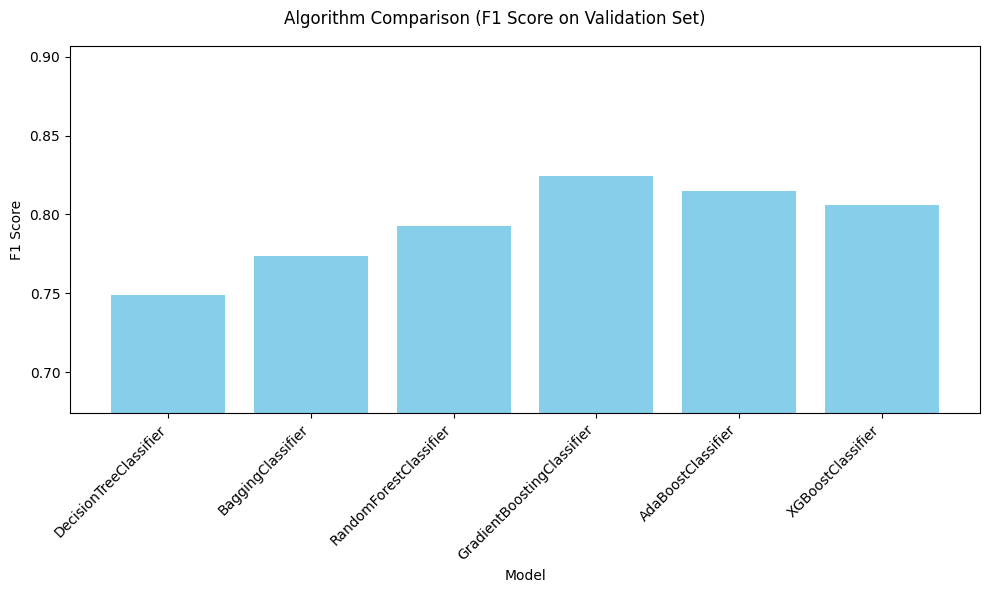

In [ ]:
# Plotting bar plot for F1 scores of all models defined above
fig = plt.figure(figsize=(10, 6)) # Adjust figure size for better readability

fig.suptitle("Algorithm Comparison (F1 Score on Validation Set)")
ax = fig.add_subplot(111)

# Create a bar plot
ax.bar(names, scores_original_validation, color='skyblue')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add labels and title
ax.set_xlabel("Model")
ax.set_ylabel("F1 Score")
ax.set_ylim(min(scores_original_validation) * 0.9, max(scores_original_validation) * 1.1) # Adjust y-axis limits

plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

### Model Building - Oversampled Data

In [ ]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=RS
)  # Synthetic Minority Over Sampling Technique
X_train_over, y_train_over = sm.fit_resample(X_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 10210
Before Oversampling, counts of label 'No': 5078 

After Oversampling, counts of label 'Yes': 10210
After Oversampling, counts of label 'No': 10210 

After Oversampling, the shape of train_X: (20420, 16)
After Oversampling, the shape of train_y: (20420,) 



In [ ]:
X_train_over.sample(10)

,education_of_employee,has_job_experience,requires_job_training,no_of_employees,prevailing_wage,full_time_position,company_age_group,continent_Asia,continent_Europe,continent_North America,continent_Oceania,continent_South America,region_of_employment_Midwest,region_of_employment_Northeast,region_of_employment_South,region_of_employment_West
6719,2,1,1,3501,64778.100,1,2,0,1,0,0,0,0,0,1,0
8593,2,1,0,815,39483.100,1,1,0,1,0,0,0,0,0,0,1
8179,2,1,0,30637,80867.150,1,3,1,0,0,0,0,1,0,0,0
19235,NaN,NaN,0,995,45268.048,1,2,1,0,0,0,0,0,0,0,0
16103,1,0,0,1261,141791.569,1,2,1,0,0,0,0,0,1,0,0
8398,1,1,0,526,70747.400,1,2,1,0,0,0,0,0,0,1,0
5457,3,0,1,1069,75940.210,1,4,0,0,0,1,0,0,0,0,1
16273,NaN,1,0,1424,79999.074,1,NaN,0,0,0,0,0,0,0,0,0
5003,2,1,0,1960,50872.540,1,4,1,0,0,0,0,0,0,0,1
10972,2,1,0,2898,59472.800,1,4,1,0,0,0,0,1,0,0,0


In [ ]:
# Identify label-encoded categorical columns where NaNs appeared
label_encoded_cols = [
    'education_of_employee',
    'has_job_experience',
    'requires_job_training',
    'full_time_position',
    'company_age_group'
]

# Round and convert to integer type to handle synthetic float values introduced by SMOTE
for col in label_encoded_cols:
    if col in X_train_over.columns:
        # Convert to float first to handle potential mixed types or ensure float operations work
        temp_col = pd.to_numeric(X_train_over[col], errors='coerce')

        # Round the float values
        rounded_values = temp_col.round()

        # Fill any NaN values with the mode of the rounded values
        # If the series is entirely NaN, mode() will be empty or return NaN.
        # In that rare case, default to 0 as a placeholder.
        fill_value = rounded_values.mode()[0] if not rounded_values.empty and not rounded_values.isnull().all() else 0

        X_train_over[col] = rounded_values.fillna(fill_value).astype(int)

# Now, let's re-check for missing values
print("Missing values after handling SMOTE interpolation:")
print(X_train_over.isna().sum())

Missing values after handling SMOTE interpolation:
education_of_employee             0
has_job_experience                0
requires_job_training             0
no_of_employees                   0
prevailing_wage                   0
full_time_position                0
company_age_group                 0
continent_Asia                    0
continent_Europe                  0
continent_North America           0
continent_Oceania                 0
continent_South America           0
region_of_employment_Midwest      0
region_of_employment_Northeast    0
region_of_employment_South        0
region_of_employment_West         0
dtype: int64


In [ ]:
models_over = []  # Empty list to store all the models

# Appending models into the list
models_over.append(("BaggingClassifier", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RS, class_weight='balanced'), random_state=RS)))
models_over.append(("RandomForestClassifier", RandomForestClassifier(random_state=RS, class_weight='balanced')))
models_over.append(("GradientBoostingClassifier", GradientBoostingClassifier(random_state=RS)))
models_over.append(("AdaBoostClassifier", AdaBoostClassifier(random_state=RS)))
models_over.append(("DecisionTreeClassifier", DecisionTreeClassifier(random_state=RS, class_weight='balanced')))
models_over.append(("XGBoostClassifier", XGBClassifier(random_state=RS, enable_categorical=True)))


print("\n" "Training Performance:" "\n")
for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_train_over, model.predict(X_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

BaggingClassifier: 0.9846062759029012
RandomForestClassifier: 0.9999510260051913
GradientBoostingClassifier: 0.7838202680551538
AdaBoostClassifier: 0.7328009828009828
DecisionTreeClassifier: 1.0
XGBoostClassifier: 0.8742800019041272

Validation Performance:

BaggingClassifier: 0.7573284980356603
RandomForestClassifier: 0.776690521396232
GradientBoostingClassifier: 0.792320093800381
AdaBoostClassifier: 0.7438891483730344
DecisionTreeClassifier: 0.7325842696629213
XGBoostClassifier: 0.6885096007314843


In [ ]:
print("\nTraining and Validation Performance Difference (Oversampled Data):\n")

for name, model in models_over:
    model.fit(X_train_over, y_train_over)
    scores_train = f1_score(y_train_over, model.predict(X_train_over))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference2 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference2))


Training and Validation Performance Difference (Oversampled Data):

BaggingClassifier: Training Score: 0.9846, Validation Score: 0.7573, Difference: 0.2273
RandomForestClassifier: Training Score: 1.0000, Validation Score: 0.7767, Difference: 0.2233
GradientBoostingClassifier: Training Score: 0.7838, Validation Score: 0.7923, Difference: -0.0085
AdaBoostClassifier: Training Score: 0.7328, Validation Score: 0.7439, Difference: -0.0111
DecisionTreeClassifier: Training Score: 1.0000, Validation Score: 0.7326, Difference: 0.2674
XGBoostClassifier: Training Score: 0.8743, Validation Score: 0.6885, Difference: 0.1858


Based on the training and validation F1-scores for the models trained with oversampled data, here are the observations:

**Overfitting**:

* `DecisionTreeClassifier`: Training F1: 1.0000, Validation F1: 0.7326 (Difference: 0.2674). This model heavily overfits the training data, showing a large drop in performance on unseen validation data.

* `BaggingClassifier`: Training Score: 0.9846, Validation Score: 0.7573 (Difference: 0.2273). While performing better than a single Decision Tree, it still exhibits significant overfitting.

* `RandomForestClassifier`: Training F1: 1.0000, Validation F1: 0.7767 (Difference: 0.2233). Similar to BaggingClassifier, it shows strong overfitting.

* `XGBoostClassifier`: Training F1: 0.8743, Validation F1: 0.6885 (Difference: 0.1858). This model also shows a notable difference between training and validation scores, indicating overfitting.

**Generalizing Well (or slightly underfitting, which is better than overfitting for unseen data):**

* `GradientBoostingClassifier`: Training F1: 0.7838, Validation F1: 0.7923 (Difference: -0.0085). This model shows excellent generalization, with its validation score slightly higher than its training score, suggesting it handles unseen data well.

* `AdaBoostClassifier`: Training F1: 0.7328, Validation F1: 0.7439 (Difference: -0.0111). Similar to GradientBoostingClassifier, AdaBoost also generalizes well, with a slightly better performance on the validation set.

### Model Building - Undersampled Data

In [ ]:
rus = RandomUnderSampler(random_state=RS)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 10210
Before Under Sampling, counts of label 'No': 5078 

After Under Sampling, counts of label 'Yes': 5078
After Under Sampling, counts of label 'No': 5078 

After Under Sampling, the shape of train_X: (10156, 16)
After Under Sampling, the shape of train_y: (10156,) 



In [ ]:
models_under = []  # Empty list to store all the models

# Appending models into the list
models_under.append(("BaggingClassifier", BaggingClassifier(estimator=DecisionTreeClassifier(random_state=RS, class_weight='balanced'), random_state=RS)))
models_under.append(("RandomForestClassifier", RandomForestClassifier(random_state=RS, class_weight='balanced')))
models_under.append(("GradientBoostingClassifier", GradientBoostingClassifier(random_state=RS)))
models_under.append(("AdaBoostClassifier", AdaBoostClassifier(random_state=RS)))
models_under.append(("DecisionTreeClassifier", DecisionTreeClassifier(random_state=RS, class_weight='balanced')))
models_under.append(("XGBoostClassifier", XGBClassifier(random_state=RS, enable_categorical=True)))


print("\n" "Training Performance:" "\n")
for name, model in models_under:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_train_un, model.predict(X_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Validation Performance:" "\n")

for name, model in models_under:
    model.fit(X_train_un, y_train_un)
    scores = f1_score(y_val, model.predict(X_val))
    print("{}: {}".format(name, scores))


Training Performance:

BaggingClassifier: 0.9798564020741922
RandomForestClassifier: 1.0
GradientBoostingClassifier: 0.7263950569608032
AdaBoostClassifier: 0.6903156454607642
DecisionTreeClassifier: 1.0
XGBoostClassifier: 0.8607719574635684

Validation Performance:

BaggingClassifier: 0.680865564832169
RandomForestClassifier: 0.7234112073190655
GradientBoostingClassifier: 0.7726130653266332
AdaBoostClassifier: 0.7523081821076091
DecisionTreeClassifier: 0.6916192026037429
XGBoostClassifier: 0.7431781701444623


In [ ]:
print("\nTraining and Validation Performance Difference:\n")

for name, model in models_under:
    model.fit(X_train_un, y_train_un)
    scores_train = f1_score(y_train_un, model.predict(X_train_un))
    scores_val = f1_score(y_val, model.predict(X_val))
    difference3 = scores_train - scores_val
    print("{}: Training Score: {:.4f}, Validation Score: {:.4f}, Difference: {:.4f}".format(name, scores_train, scores_val, difference3))


Training and Validation Performance Difference:

BaggingClassifier: Training Score: 0.9799, Validation Score: 0.6809, Difference: 0.2990
RandomForestClassifier: Training Score: 1.0000, Validation Score: 0.7234, Difference: 0.2766
GradientBoostingClassifier: Training Score: 0.7264, Validation Score: 0.7726, Difference: -0.0462
AdaBoostClassifier: Training Score: 0.6903, Validation Score: 0.7523, Difference: -0.0620
DecisionTreeClassifier: Training Score: 1.0000, Validation Score: 0.6916, Difference: 0.3084
XGBoostClassifier: Training Score: 0.8608, Validation Score: 0.7432, Difference: 0.1176


Even in Undersampled models, we see BaggingClassifier, RandomForestClassifier, DecisionTreeClassifier are highly overfitting.

GradientBoostingClassifier, AdaBoostClassifier, XGBoostClassifier(this is not overfitting but its not generalizing well on validation data as the f1 score drops from 86% to 74% which is not good score) are not overfitting but generalizing well with minimum differences from training to validation data sets.


**Performance of Models with Resampled Data (Oversampling & Undersampling):**

**Oversampled Data:**

- **GradientBoostingClassifier**:
Validation F1: 0.7923 (Good generalization: Difference: -0.0085)

- **AdaBoostClassifier**: Validation F1: 0.7439 (Good generalization: Difference: -0.0111)

**Undersampled Data:**

- **GradientBoostingClassifier**: Validation F1: 0.7726 (Good generalization: Difference: -0.0462)

- **AdaBoostClassifier**: Validation F1: 0.7523 (Good generalization: Difference: -0.0620)

**Key Observations:**

* The **GradientBoostingClassifier** , **AdaBoostClassifier**,  **XGBoostClassifier** trained on the original (unbalanced) data yielded the highest F1-scores on the validation set and demonstrated very good generalization, with minimal differences between training and validation performance.


* While oversampling and undersampling  models generalize better (like GBM and AdaBoost, often showing slightly better validation than training scores), they did not exceed the F1-score achieved by the GradientBoostingClassifier and AdaBoostClassifier on the original data.


* Tree-based ensemble models like DecisionTreeClassifier, BaggingClassifier, and RandomForestClassifier consistently showed significant overfitting (large positive difference between training and validation F1-scores) across all data handling strategies.


**Conclusion**:

Based on the validation F1-scores and generalization performance, the **GradientBoostingClassifier trained on the original data** is the best performing model so far, closely followed by the **AdaBoostClassifier on original data**, **XGBoostClassifier on original data**. These models strike the best balance between predictive power and avoiding overfitting for this specific dataset and metric.

## Hyperparameter Tuning

### Tuning AdaBoostClassifier model with Original data

In [ ]:
%%time

# defining model
Model = AdaBoostClassifier(random_state=RS)

# Parameter grid to pass in RandomSearchCV
param_grid = {
    "n_estimators": np.arange(10, 40, 10),
    "learning_rate": [0.1, 0.01, 0.2, 0.05, 1],
    "estimator": [
        DecisionTreeClassifier(max_depth=1, random_state=RS),
        DecisionTreeClassifier(max_depth=2, random_state=RS),
        DecisionTreeClassifier(max_depth=3, random_state=RS),
    ],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_jobs = -1, n_iter=50, scoring=scorer, cv=5, random_state=RS)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train, y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'n_estimators': np.int64(30), 'learning_rate': 1, 'estimator': DecisionTreeClassifier(max_depth=1, random_state=1)} with CV score=0.8165672968866771:
CPU times: user 1.8 s, sys: 178 ms, total: 1.98 s
Wall time: 1min 6s


In [ ]:
tuned_adb = AdaBoostClassifier(
    random_state=RS,
    n_estimators=30,
    learning_rate=1,
    estimator=DecisionTreeClassifier(max_depth=1, random_state=RS),
)
tuned_adb.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=1),
                   learning_rate=1, n_estimators=30, random_state=1)

In [ ]:
# Checking model's performance on training set
adb_train = model_performance_classification_sklearn(tuned_adb, X_train, y_train)
adb_train

,Accuracy,Recall,Precision,F1
0,0.736,0.887,0.759,0.818


In [ ]:
# Checking model's performance on validation set
adb_val = model_performance_classification_sklearn(tuned_adb, X_val, y_val)
adb_val

,Accuracy,Recall,Precision,F1
0,0.732,0.881,0.758,0.815


### Tuning  Gradient Boosting model with Original Data

In [ ]:
%%time

#Creating pipeline
Model = GradientBoostingClassifier(random_state=RS)

#Parameter grid to pass in RandomSearchCV
param_grid = {
    "init": [AdaBoostClassifier(random_state=RS),DecisionTreeClassifier(random_state=RS)],
    "n_estimators": np.arange(125,175,25),
    "learning_rate": [0.01, 0.2, 0.05, 1],
    "subsample":[0.8,0.9,1],
    "max_features":[0.5,0.7,1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
randomized_cv = RandomizedSearchCV(estimator=Model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=RS, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
randomized_cv.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(randomized_cv.best_params_,randomized_cv.best_score_))

Best parameters are {'subsample': 0.8, 'n_estimators': np.int64(150), 'max_features': 0.7, 'learning_rate': 0.05, 'init': AdaBoostClassifier(random_state=1)} with CV score=0.819820054540379:
CPU times: user 5.47 s, sys: 446 ms, total: 5.92 s
Wall time: 5min 52s


In [ ]:
tuned_gbm1 = GradientBoostingClassifier(
    random_state=RS,
    subsample= 0.8,
    n_estimators=150,
    max_features=0.7,
    learning_rate=0.05,
    init=AdaBoostClassifier(random_state=RS),
)
tuned_gbm1.fit(X_train, y_train)

GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=150, random_state=1, subsample=0.8)

In [ ]:
# Checking model's performance on training set
gbm1_train = model_performance_classification_sklearn(
    tuned_gbm1, X_train, y_train
)
gbm1_train

,Accuracy,Recall,Precision,F1
0,0.750,0.879,0.776,0.824


In [ ]:
# Checking model's performance on validation set
gbm1_val = model_performance_classification_sklearn(tuned_gbm1, X_val, y_val)
gbm1_val

,Accuracy,Recall,Precision,F1
0,0.746,0.873,0.775,0.821


### Tuning  XGBoost model with Original Data

In [ ]:
%%time

# defining model
model = XGBClassifier(random_state=RS,eval_metric='logloss', enable_categorical = True)

# Parameter grid to pass in RandomizedSearchCV
param_grid={'n_estimators':np.arange(50,150,50),
            'scale_pos_weight':[2,5,10],
            'learning_rate':[0.01,0.1,0.2,0.05],
            'gamma':[0,1,3,5],
            'subsample':[0.8,0.9,1],
            'max_depth':np.arange(1,5,1),
            'reg_lambda':[5,10]}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.f1_score)

#Calling RandomizedSearchCV
xgb_tuned = RandomizedSearchCV(estimator=model, param_distributions=param_grid, n_iter=50, scoring=scorer, cv=5, random_state=RS, n_jobs = -1)

#Fitting parameters in RandomizedSearchCV
xgb_tuned.fit(X_train,y_train)

print("Best parameters are {} with CV score={}:" .format(xgb_tuned.best_params_,xgb_tuned.best_score_))

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 2, 'reg_lambda': 10, 'n_estimators': np.int64(100), 'max_depth': np.int64(4), 'learning_rate': 0.2, 'gamma': 1} with CV score=0.8185329142013131:
CPU times: user 1.76 s, sys: 193 ms, total: 1.96 s
Wall time: 32.2 s


In [ ]:
# building model with best parameters
xgb_tuned = XGBClassifier(enable_categorical = True,
    random_state=1,
    n_estimators=100,
    scale_pos_weight=2,
    gamma=1,
    subsample=0.9,
    learning_rate=0.2,
    eval_metric="logloss",
    max_depth=4,
    reg_lambda=10,
)
# Fit the model on training data
xgb_tuned.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.2, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Checking model's performance on training set
xgb_tuned_train_perf = model_performance_classification_sklearn(
    xgb_tuned, X_train, y_train
)
xgb_tuned_train_perf

,Accuracy,Recall,Precision,F1
0,0.743,0.971,0.732,0.835


In [ ]:
# Checking model's performance on validation set
xgb_tuned_validation_perf = model_performance_classification_sklearn(xgb_tuned, X_val, y_val)
xgb_tuned_validation_perf

,Accuracy,Recall,Precision,F1
0,0.717,0.949,0.718,0.818


## Model Comparison and Final Model Selection

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
      gbm1_train.T, adb_train.T, xgb_tuned_train_perf.T
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Original data",
    "XGBoost tained with Original data"
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Gradient boosting trained with Original data,AdaBoost trained with Original data,XGBoost tained with Original data
Accuracy,0.750,0.736,0.743
Recall,0.879,0.887,0.971
Precision,0.776,0.759,0.732
F1,0.824,0.818,0.835


In [ ]:
# Validation performance comparison

models_train_comp_df = pd.concat(
    [ gbm1_val.T, adb_val.T,xgb_tuned_validation_perf.T ], axis=1,
)
models_train_comp_df.columns = [
    "Gradient boosting trained with Original data",
    "AdaBoost trained with Original data",
    "XGBoost tained with Original data"
]
print("Validation performance comparison:")
models_train_comp_df

Validation performance comparison:


,Gradient boosting trained with Original data,AdaBoost trained with Original data,XGBoost tained with Original data
Accuracy,0.746,0.732,0.717
Recall,0.873,0.881,0.949
Precision,0.775,0.758,0.718
F1,0.821,0.815,0.818


When we validate the train and  validation performance, we dont see overfitting in all the three models. All the three are generalizing well and we have good f1 scores around 80%.

Recall is also good and around and above 85%


### Model Comparison on Validation Set (F1-score):

*   **Gradient boosting trained with Original data**: F1-score = 0.821
*   **AdaBoost trained with Original data**: F1-score = 0.815
*   **XGBoost trained with Original data**: F1-score = 0.818

**Conclusion**: The **Gradient Boosting Classifier trained with Original data** has the highest F1-score (0.818) on the validation set among the tuned models. Therefore, I will select any one modle among these two as the best performing model for further evaluation on the test set.

I will select  the `Gradient Boosting Classifier trained with Original data` and check its performance on test data.

In [ ]:
# Let's check the performance on test set
gbm1_test = model_performance_classification_sklearn(tuned_gbm1, X_test, y_test)
gbm1_test

,Accuracy,Recall,Precision,F1
0,0.736,0.875,0.764,0.816


### Generate Feature imporances for Gradient Boosting tuned model.

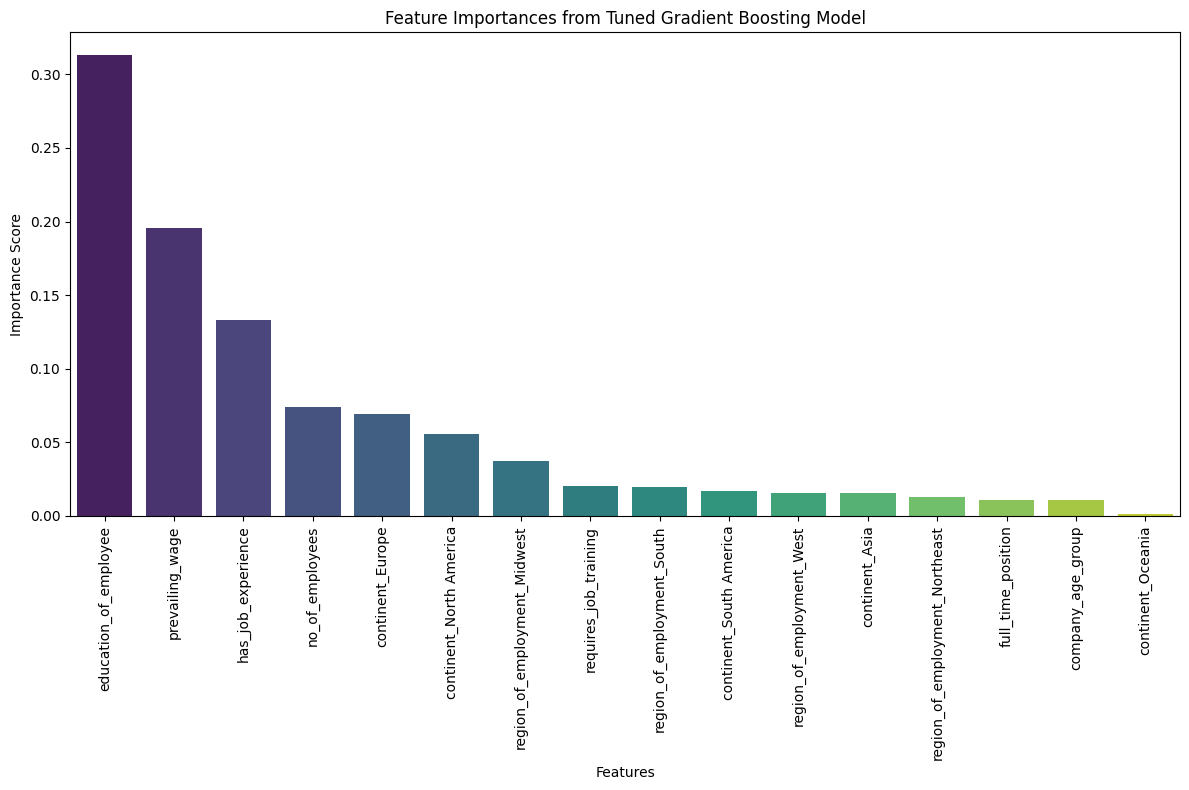

In [ ]:
importances = tuned_gbm1.feature_importances_
feature_names = X_train.columns

# Create a Series for better handling and sorting
feature_importances = pd.Series(importances, index=feature_names)

# Sort the feature importances in descending order
feature_importances = feature_importances.sort_values(ascending=False)

# Plotting the feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=feature_importances.index, y=feature_importances.values, palette='viridis')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importances from Tuned Gradient Boosting Model')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Business Insights and Recommendations

Based on the feature importances derived from the `tuned_gbm1` model, the following insights and recommendations can be provided:

**Top Influential Features:**

1.  **education_of_employee (~0.419)**: This is by far the most significant factor influencing visa certification. Higher education levels (Doctorate, Master's, Bachelor's) are strongly correlated with higher certification rates.

2.  **prevailing_wage (~0.19)**: The prevailing wage offered for the position is the second most important numerical feature. Higher wages generally indicate higher chances of certification.

3.  **has_job_experience (~0.144)**: Possessing prior job experience is another crucial factor, significantly contributing to the likelihood of visa approval.

4.  **no_of_employees (~0.07)**: While less impactful than education or wage, the number of employees in the employer's company still plays a role.

5.  **continent_Europe (~0.06)**: Applicants from Europe have a notably higher impact on certification than other continents, indicating a preferential or higher success rate.

6.   **continent_north_America (~0.05)**: Applicants from North America have a notably higher impact on certification than other continents, indicating a preferential or higher success rate.

7.  **region_of_employment_Midwest (~0.04)**: The region of employment, particularly the Midwest, shows some influence.

8.  **requires_job_training (~0.030)**: Interestingly, the requirement for job training has a moderate influence, suggesting that applications for roles requiring training are not necessarily disadvantaged.


**Actionable Recommendations for EasyVisa:**

1.  **Prioritize Applications based on Education and Experience**: EasyVisa should develop a preliminary screening mechanism that gives higher weightage to applicants with higher educational qualifications (Master's, Doctorate) and prior job experience. This can streamline the process for high-probability cases.
    *   **Recommendation**: Implement a tiered processing system where applications with 'Doctorate' or 'Master's' degrees and 'has_job_experience=Y' receive expedited initial review.

2.  **Focus on Prevailing Wage Compliance and Competitiveness**: Guide employers to ensure the prevailing wage offered is competitive and meets or exceeds the industry standards, as it is a strong predictor of certification.
    *   **Recommendation**: Provide employers with data-driven insights on optimal prevailing wage ranges for different roles and regions to maximize certification chances. Highlight the importance of presenting these wages clearly in applications.

3.  **Strategic Guidance for Employers on Applicant Profiles**: Advise employers to seek candidates with strong educational backgrounds and relevant experience. For positions where training is required, ensure a clear justification is provided.
    *   **Recommendation**:  Develop a comprehensive guide for employers, emphasizing the profile of successful applicants and providing templates for justification when job training is a requirement.

4. **Leverage Geographical Insights**: Utilize the influence of continent and region of employment to offer tailored advice.

    *  **Recommendation**: Create region-specific advisory modules, for example, by providing additional guidance or resources for applicants from continents or regions with lower certification rates, or for specific industries prevalent in high-certification regions like the Midwest.

5. **Refine Company Profiling**: Advise new businesses on strategies to mitigate the lower certification rates observed for 'Very Young' companies.

   * **Recommendation**: Offer specialized consulting for 'Very Young' companies, focusing on strengthening other aspects of their application to compensate for their newness, or setting realistic expectations about certification timelines and probabilities.